<a href="https://colab.research.google.com/github/abussing/abussing/blob/main/sfm_piece1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bayesian Spatial Factor Model — Piece 1

**Simulation + MAP initialization + Diagnostics**

Set runtime to **GPU** (Runtime → Change runtime type → T4/A100)

## 1 — Install

In [ ]:
# If R packages already cached on Drive, restore them:
# from google.colab import drive
# drive.mount('/content/drive')
# !tar xzf /content/drive/MyDrive/sfm_cache/r_site_library.tar.gz -C /usr/local/lib/R/site-library

!apt-get update -qq
!apt-get install -qq -y r-base r-base-dev libgdal-dev libgeos-dev libproj-dev libsqlite3-dev > /dev/null 2>&1
!rm -rf /usr/local/lib/R/site-library/00LOCK-*
!R -e 'install.packages(c("fmesher","Matrix"), repos="https://cran.r-project.org")'
!pip install -q blackjax

import jax
jax.config.update("jax_enable_x64", True)
print(f"JAX {jax.__version__}, backend: {jax.default_backend()}, devices: {jax.devices()}")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)

R version 4.5.3 (2026-03-11) -- "Reassured Reassurer"
Copyright (C) 2026 The R Foundation for Statistical Computing
Platform: x86_64-pc-linux-gnu

R is free software and comes with ABSOLUTELY NO WARRANTY.
You are welcome to redistribute it under certain conditions.
Type 'license()' or 'licence()' for distribution details.

  Natural language support but running in an English locale

R is a collaborative project with many contributors.
Type 'contributors()' for more information and
'citation()' on how to cite R or R packages in publications.

Type 'demo()' for some demos, 'help()' for on-line help, or
'help.start()' for an HTML browser interface to help.
Type 'q()' to quit R.

> install.packages(c("fmesher","Matrix"), repos="https://cran.r-project.org")
Installing packages into ‘/usr/local/lib/R/site

## 2 — Configuration

All knobs in one place.

In [1]:
import math, os, json, subprocess, csv, time
import numpy as np
import scipy.linalg as sla
import scipy.optimize as opt
import scipy.special as sp
from scipy.spatial.distance import cdist, pdist, squareform

import jax
import jax.numpy as jnp
import jax.random as jr
import blackjax

import matplotlib.pyplot as plt
from IPython.display import clear_output, display

jax.config.update("jax_enable_x64", True)

# ── workspace ──
WORKDIR = "/content/sfm"
RUNDIR  = os.path.join(WORKDIR, "run01")
R_EXPORT_DIR = os.path.join(RUNDIR, "r_export")
os.makedirs(R_EXPORT_DIR, exist_ok=True)

# ── smoothness (one value, used everywhere) ──
NU = 5.0

# ── seeds ──
SEED     = 21
FIT_SEED = 231

# ── truth dimensions ──
C              = 3
G              = 50
K_TRUE         = 3
CELLS_PER_TYPE = (100, 100, 100)
N              = sum(CELLS_PER_TYPE)
M              = 128       # RFF features (also used for MAP's standalone RFF)

# ── MAP: K_FIT can be > K_TRUE (overcomplete) ──
K_FIT = 5

# ── truth hyperparameters (per-factor, deep GP) ──
TRUE_ALPHA   = [5.0, 4.0, 3.0]
TRUE_THETA_Y = [2.5, 1.75, 1.25]
TRUE_RHO     = [0.6, 0.7, 0.8]
TRUE_ZETA    = [0.9, 0.7, 0.4]
SIGMA_RANGE  = (2.0/3, 3.0/3)    # noise std drawn U[lo, hi] per gene
S_VALUES     = [0.95, 0.95, 0.95] # cross-CT loading correlation

# ── Lambda generation ──
LAMBDA_PATTERN = "celltype_rewire"
CAP            = 1.5
PHI_TAU        = 1.0
NOISE_SD       = 0.05

# ── spatial layout ──
CLOUD_CENTERS = [(-1.0, -1.0), (-1.0, 1.0), (0.0, 0.0)]
CLOUD_SIDE    = 2.0

# ── MAP (Stage 0) frozen spatial hyperparameters ──
FIT_ALPHA2  = 1.0
FIT_ZETA    = 0.5
FIT_THETA_Y = 2.0
FIT_B       = FIT_ALPHA2 * FIT_ZETA
FIT_B0      = FIT_ALPHA2 * (1.0 - FIT_ZETA)

# ── MAP optimizer ──
MAXITER = 5000
RIDGE   = 1e-4

# ── MAP: ARD ──
USE_ARD            = True
ARD_A_TAU          = 1.0
ARD_B_TAU          = 1e-3
ARD_TAU_INIT       = 1.0
ARD_OUTER_ITERS    = 10
ARD_LBFGS_PER_OUTER = 5000

# ── MAP: s_k prior ──
USE_S_PRIOR = True
S_FIT       = 0.9

# ── R mesh ──
ALPHA_FEM = 6
CUTOFF    = 0.1

# ── gene sets ──
GPF = G // K_TRUE
GENE_SETS = [list(range(k * GPF, (k + 1) * GPF)) for k in range(K_TRUE)]

print("Config OK")
print(f"  N={N} G={G} K_TRUE={K_TRUE} K_FIT={K_FIT} C={C} M={M} NU={NU}")
print(f"  alpha  = {TRUE_ALPHA}")
print(f"  theta  = {TRUE_THETA_Y}")
print(f"  rho    = {TRUE_RHO}")
print(f"  zeta   = {TRUE_ZETA}")
print(f"  MAP: b={FIT_B} b0={FIT_B0} theta_y={FIT_THETA_Y}")
print(f"  ARD={USE_ARD} S_PRIOR={USE_S_PRIOR} s={S_FIT}")

ModuleNotFoundError: No module named 'blackjax'

## 3 — Shared Utilities

In [ ]:
# ── dense Matérn covariance ──
def matern_covariance(dist, range_param, nu=NU, variance=1.0):
    kappa = math.sqrt(8.0 * nu) / range_param
    x = kappa * np.asarray(dist, dtype=np.float64)
    out = np.full_like(x, variance, dtype=np.float64)
    nz = x > 0
    if np.any(nz):
        xnz = x[nz]
        prefactor = (2.0**(1.0 - nu)) / sp.gamma(nu)
        out[nz] = variance * prefactor * (xnz**nu) * sp.kv(nu, xnz)
    return out

def matern_cov_matrix(coords, range_param, nu=NU, variance=1.0):
    D = squareform(pdist(coords))
    return matern_covariance(D, range_param, nu=nu, variance=variance)

# ── Lambda builders ──
def build_lambda_block_simple(G, K, C, gene_sets, s, cap=1.5, phi_tau=1.0,
                              noise_sd=0.05):
    Lambda = np.zeros((C, G, K))
    for k in range(K):
        sk = s[k]
        scale = 1.0 / phi_tau
        for g in gene_sets[k]:
            shared = np.random.normal(0.0, np.sqrt(sk * scale))
            indep = np.random.normal(0.0, np.sqrt((1.0 - sk) * scale), size=C)
            Lambda[:, g, k] = shared + indep
        non_loading = np.setdiff1d(np.arange(G), gene_sets[k])
        Lambda[:, non_loading, k] = np.random.normal(
            0.0, noise_sd, size=(C, len(non_loading)))
    Lambda = np.clip(Lambda, -cap, cap)
    return Lambda

def build_lambda_celltype_rewire(G, K, C, gene_sets, s, cap=1.5, phi_tau=1.0,
                                 noise_sd=0.05):
    Lambda = build_lambda_block_simple(G, K, C, gene_sets, s, cap=cap,
                                       phi_tau=phi_tau, noise_sd=noise_sd)
    if C >= 2 and K >= 2 and len(gene_sets) >= 2:
        for g in gene_sets[1]:
            Lambda[1, g, 0] = Lambda[1, g, 1] * 0.8
    if C >= 3 and K >= 3:
        for g in gene_sets[0]:
            Lambda[2, g, 2] = Lambda[2, g, 0]
            Lambda[2, g, 0] = 0.0
    Lambda = np.clip(Lambda, -cap, cap)
    return Lambda

LAMBDA_BUILDERS = {
    "block_simple": build_lambda_block_simple,
    "celltype_rewire": build_lambda_celltype_rewire,
}

# ── spatial layout ──
def make_spatial_layout(cells_per_type, centers, side, rng):
    C_loc = len(cells_per_type)
    half = side / 2.0
    coords_list, types_list = [], []
    for c in range(C_loc):
        nc = cells_per_type[c]
        cx, cy = centers[c]
        x = rng.uniform(cx - half, cx + half, size=nc)
        y = rng.uniform(cy - half, cy + half, size=nc)
        coords_list.append(np.column_stack([x, y]))
        types_list.append(np.full(nc, c, dtype=int))
    return np.vstack(coords_list), np.concatenate(types_list)

# ── RFF (standalone, for MAP) ──
def make_rff(coords, m, range_param, seed, nu=NU):
    rng = np.random.default_rng(seed)
    d = coords.shape[1]
    df = 2.0 * nu
    kappa = math.sqrt(8.0 * nu) / range_param
    Z = rng.normal(size=(d, m))
    U = rng.chisquare(df, size=m)
    W = kappa * Z / np.sqrt(U)[None, :]
    phase = rng.uniform(0.0, 2.0 * np.pi, size=(m,))
    return np.sqrt(2.0 / m) * np.cos(coords @ W + phase)

# ── deep GP warp field generation (dense truth) ──
def draw_warp_field(coords, rho_k, theta_yk, nu=NU, seed=None):
    rng = np.random.default_rng(seed)
    N_loc = coords.shape[0]
    inner_range = rho_k * theta_yk
    K_inner = matern_cov_matrix(coords, range_param=inner_range, nu=nu)
    K_inner += 1e-8 * np.eye(N_loc)
    L_inner = np.linalg.cholesky(K_inner)
    W1k = L_inner @ rng.normal(size=N_loc)
    W2k = L_inner @ rng.normal(size=N_loc)
    return np.column_stack([W1k, W2k])

def draw_eta_spatial(warped_coords_k, theta_yk, nu=NU, seed=None):
    rng = np.random.default_rng(seed)
    N_loc = warped_coords_k.shape[0]
    K_outer = matern_cov_matrix(warped_coords_k, range_param=theta_yk, nu=nu)
    K_outer += 1e-8 * np.eye(N_loc)
    L_outer = np.linalg.cholesky(K_outer)
    return L_outer @ rng.normal(size=N_loc)


def to_logit(p, eps=1e-3):
    p_raw = np.clip((p - eps) / (1.0 - 2.0 * eps), 1e-6, 1.0 - 1e-6)
    return float(np.log(p_raw / (1.0 - p_raw)))

def from_logit(l, eps=1e-3):
    return float(eps + (1.0 - 2.0 * eps) / (1.0 + np.exp(-float(l))))

# ── index helpers ──
def get_Lambda_ck(Lambda, cell_type, k):
    return Lambda[cell_type, :, k]

def compute_base_stats(R_minus_k, Lambda_ck, sigma2):
    inv_sig2 = 1.0 / sigma2
    Lam_s = Lambda_ck * inv_sig2[np.newaxis, :]
    u_k = np.sum(Lambda_ck * Lam_s, axis=1)
    ctilde_k = np.sum(Lam_s * R_minus_k.T, axis=1)
    return u_k, ctilde_k

def compute_alpha_Lambda(alpha, Lambda):
    C, G, K_fac = Lambda.shape
    aL = np.zeros_like(Lambda)
    for k in range(K_fac): aL[:, :, k] = alpha[k] * Lambda[:, :, k]
    return aL

def pick_diagnostic_subset(K_fac, G_dim, N_dim, gene_sets_raw):
    np.random.seed(999)
    gene_idx = []
    for gs in gene_sets_raw:
        block = np.arange(gs[0], gs[1])
        gene_idx.append(block[:3])
    gene_idx = np.sort(np.concatenate(gene_idx))
    cell_idx = np.sort(np.linspace(0, N_dim - 1, 15, dtype=int))
    np.random.seed()
    return gene_idx, cell_idx

def build_joint_cov(W1, W2, log_thetay, logit_zeta, alpha, Lambda, sigma2,
                    gi, ci, cell_type, K_fac, nu=NU):
    ng, nc = len(gi), len(ci)
    Cov = np.zeros((ng * nc, ng * nc))
    K_eta_list = []
    for k in range(K_fac):
        W_k = np.column_stack([W1[ci, k], W2[ci, k]])
        th_k = float(np.exp(log_thetay[k]))
        ze_k = float(np.clip(1.0 / (1.0 + np.exp(-logit_zeta[k])), 0.0, 1.0))
        K_spat = matern_covariance(squareform(pdist(W_k)), range_param=th_k, nu=nu)
        K_eta_list.append(ze_k * K_spat + (1.0 - ze_k) * np.eye(nc))
    for a, ga in enumerate(gi):
        for b, gb in enumerate(gi):
            for ii in range(nc):
                for jj in range(nc):
                    c_i, c_j = cell_type[ci[ii]], cell_type[ci[jj]]
                    val = 0.0
                    for k in range(K_fac):
                        val += alpha[k]**2 * Lambda[c_i, ga, k] * Lambda[c_j, gb, k] * K_eta_list[k][ii, jj]
                    if ga == gb and ii == jj:
                        val += sigma2[ga]
                    Cov[a * nc + ii, b * nc + jj] = val
    return Cov

print("Utilities defined")

Utilities defined


## 4 — R Export: SPDE Mesh + RFF Features

This runs the R script to build the mesh + FEM matrices + RFF frequencies.
The SPDE/RFF machinery is only needed for the MCMC sampler (Piece 2).
The MAP stage uses its own standalone RFF via `make_rff()`.

In [ ]:
R_SCRIPT = r'''
library(fmesher)
library(Matrix)

set.seed({seed})
outdir <- "{outdir}"
dir.create(outdir, recursive = TRUE, showWarnings = FALSE)

alpha_fem <- {alpha_fem}L
cutoff <- {cutoff}
M <- {M}L
N <- {N}L

K_groups <- 3L
centers <- rbind(c(-1, -1), c(-1, 1), c(0, 0))
half_side <- {side} / 2
n_per <- rep(N %/% K_groups, K_groups)
rem <- N - sum(n_per)
if (rem > 0) n_per[1:rem] <- n_per[1:rem] + 1L
group_id <- rep(seq_len(K_groups), times = n_per)

x <- numeric(N); y <- numeric(N); start <- 1L
for (k in seq_len(K_groups)) {{
  nk <- n_per[k]; idx <- start:(start + nk - 1L)
  x[idx] <- runif(nk, min = centers[k,1] - half_side, max = centers[k,1] + half_side)
  y[idx] <- runif(nk, min = centers[k,2] - half_side, max = centers[k,2] + half_side)
  start <- start + nk
}}
slocs <- cbind(x, y)
write.csv(data.frame(x=slocs[,1], y=slocs[,2], group_id=group_id,
          group=paste0("type", group_id)),
          file.path(outdir, "slocs.csv"), row.names=FALSE)

mesh <- fm_mesh_2d(loc=slocs, boundary=fm_extensions(slocs, 5),
                   max.edge=10, cutoff=cutoff, min.angle=25)
n_v <- mesh$n
fem <- fm_fem(mesh, order=alpha_fem)
d_manifold <- fm_manifold_dim(mesh)
nu_fem <- alpha_fem - d_manifold / 2.0
C0 <- fem$c0
writeMM(C0, file.path(outdir, "fem_C.mtx"))
for (kk in seq_len(alpha_fem)) writeMM(fem[[paste0("g",kk)]], file.path(outdir, sprintf("fem_g%d.mtx", kk)))
A <- fm_basis(mesh, loc=slocs)
writeMM(A, file.path(outdir, "A.mtx"))

nu_rff <- alpha_fem - 1; theta_ref <- 2.0; kappa_ref <- sqrt(8*nu_rff)/theta_ref
Z_freq <- matrix(rnorm(M*2), ncol=2)
U_freq <- rchisq(M, df=2*nu_rff)
omega_ref <- kappa_ref * Z_freq / sqrt(U_freq)
b_rff <- runif(M, 0, 2*pi)
write.csv(data.frame(omega1=omega_ref[,1], omega2=omega_ref[,2]), file.path(outdir, "omega.csv"), row.names=FALSE)
write.csv(data.frame(b=b_rff), file.path(outdir, "b.csv"), row.names=FALSE)

write.csv(data.frame(N=N, n_v=n_v, M=M, alpha_fem=alpha_fem, d=d_manifold,
          nu_fem=nu_fem, nu_rff=nu_rff, theta_ref=theta_ref, cutoff=cutoff, seed={seed}),
          file.path(outdir, "meta.csv"), row.names=FALSE)

cat(sprintf("DONE: N=%d n_v=%d M=%d alpha=%d nu_fem=%.1f nu_rff=%.1f\n",
            N, n_v, M, alpha_fem, nu_fem, nu_rff))
'''.format(seed=SEED, outdir=R_EXPORT_DIR, alpha_fem=ALPHA_FEM,
           cutoff=CUTOFF, M=M, N=N, side=CLOUD_SIDE)

r_path = os.path.join(WORKDIR, "export.R")
with open(r_path, "w") as f:
    f.write(R_SCRIPT)
result = subprocess.run(["Rscript", r_path], capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)
    raise RuntimeError("R script failed")

NULL
NULL
DONE: N=300 n_v=409 M=128 alpha=6 nu_fem=5.0 nu_rff=5.0



## 5 — Simulate Ground-Truth Data

Dense Matérn for truth.  Warp fields and eta use per-factor seeds.
Alpha is baked into eta, matching the original script exactly.

Drawing warp fields and spatial eta from dense Matern (nu=5.0)...
  Factor 0: theta_y=2.50, rho=0.60, inner_range=1.50, warp std=(0.741, 0.592), eta std=4.271
  Factor 1: theta_y=1.75, rho=0.70, inner_range=1.22, warp std=(0.689, 0.765), eta std=3.459
  Factor 2: theta_y=1.25, rho=0.80, inner_range=1.00, warp std=(0.873, 0.749), eta std=2.899

Data: Y (300, 50), SNR median=4.19
Gene sets: ['F0: genes 0-15', 'F1: genes 16-31', 'F2: genes 32-47']


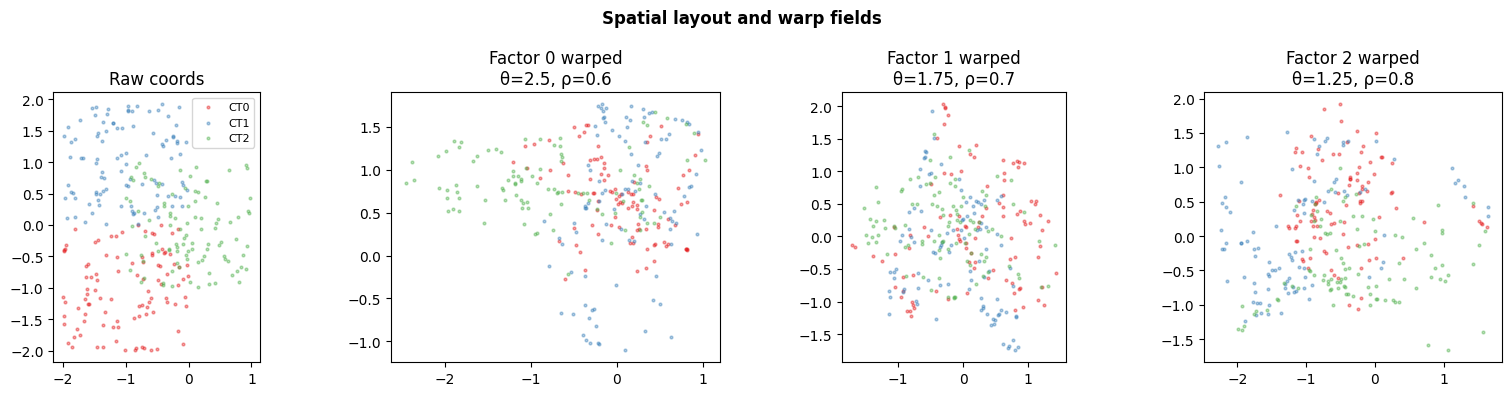

In [ ]:
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

coords, cell_types = make_spatial_layout(CELLS_PER_TYPE, CLOUD_CENTERS, CLOUD_SIDE, rng)

true_alpha   = TRUE_ALPHA[:K_TRUE]
true_zeta    = TRUE_ZETA[:K_TRUE]
true_theta_y = TRUE_THETA_Y[:K_TRUE]
true_rho     = TRUE_RHO[:K_TRUE]

# ── warp fields + eta (per-factor seeds, matching original) ──
print(f"Drawing warp fields and spatial eta from dense Matern (nu={NU})...")
warped_coords = []
eta = np.zeros((N, K_TRUE))

for k in range(K_TRUE):
    wc_k = draw_warp_field(coords, true_rho[k], true_theta_y[k],
                           nu=NU, seed=SEED + 200 + k)
    warped_coords.append(wc_k)

    eta_spat_k = draw_eta_spatial(wc_k, true_theta_y[k],
                                   nu=NU, seed=SEED + 300 + k)
    nu_k = rng.normal(size=N)

    # alpha baked into eta
    eta[:, k] = true_alpha[k] * (np.sqrt(true_zeta[k]) * eta_spat_k
                                  + np.sqrt(1.0 - true_zeta[k]) * nu_k)

    print(f"  Factor {k}: theta_y={true_theta_y[k]:.2f}, rho={true_rho[k]:.2f}, "
          f"inner_range={true_rho[k]*true_theta_y[k]:.2f}, "
          f"warp std=({np.std(wc_k[:,0]):.3f}, {np.std(wc_k[:,1]):.3f}), "
          f"eta std={np.std(eta[:,k]):.3f}")

# ── RFF for MAP (on raw coords, no warp) ──
Z_fit = make_rff(coords, m=M, range_param=FIT_THETA_Y, seed=SEED + 1)

# ── Lambda ──
builder = LAMBDA_BUILDERS[LAMBDA_PATTERN]
Lambda_3d = builder(G=G, K=K_TRUE, C=C, gene_sets=GENE_SETS, s=S_VALUES,
                    cap=CAP, phi_tau=PHI_TAU, noise_sd=NOISE_SD)
true_lambdas = [Lambda_3d[c] for c in range(C)]   # list of (G, K_TRUE) arrays

# ── Noise ──
sigma = rng.uniform(SIGMA_RANGE[0], SIGMA_RANGE[1], size=G)
sigma2 = sigma**2

# ── Y  (N x G, matching original) ──
Y = np.zeros((N, G))
for i in range(N):
    c = int(cell_types[i])
    Y[i] = true_lambdas[c] @ eta[i] + rng.normal(scale=sigma, size=G)

snr = np.var(Y, axis=0) / sigma2  # rough SNR
print(f"\nData: Y {Y.shape}, SNR median={np.median(snr):.2f}")
print(f"Gene sets: {[f'F{k}: genes {gs[0]}-{gs[-1]}' for k, gs in enumerate(GENE_SETS)]}")

# ── plot layout + warps ──
fig, axes = plt.subplots(1, K_TRUE + 1, figsize=(4*(K_TRUE+1), 4))
colors_ct = ["#e41a1c", "#377eb8", "#4daf4a"]
ax = axes[0]
for c in range(C):
    m = cell_types == c
    ax.scatter(coords[m,0], coords[m,1], s=4, alpha=0.4, color=colors_ct[c], label=f"CT{c}")
ax.set_title("Raw coords"); ax.legend(fontsize=8); ax.set_aspect("equal")
for k in range(K_TRUE):
    ax = axes[k+1]
    wc = warped_coords[k]
    for c in range(C):
        m = cell_types == c
        ax.scatter(wc[m,0], wc[m,1], s=4, alpha=0.4, color=colors_ct[c])
    ax.set_title(f"Factor {k} warped\nθ={true_theta_y[k]}, ρ={true_rho[k]}")
    ax.set_aspect("equal")
plt.suptitle("Spatial layout and warp fields", fontweight="bold")
plt.tight_layout(); plt.show()

## 6 — MAP Functions

Copied near-verbatim from the original `starting_value_finder` script.
`phi_gk` is dropped (was always 1.0 in MAP).

In [ ]:
# ── sufficient statistics ──
def split_by_type_map(Y_NxG, Z, cell_types_arr, C_val):
    stats = []
    for c in range(C_val):
        mask = cell_types_arr == c
        Yc, Zc = Y_NxG[mask], Z[mask]
        stats.append({"Y": Yc, "Z": Zc, "R": Yc.T @ Yc, "T": Zc.T @ Yc,
                      "S": Zc.T @ Zc, "Nc": int(mask.sum())})
    return stats

# ── packing ──
def pack_params(lambdas, log_sigma2):
    parts = [np.asarray(L).reshape(-1) for L in lambdas] + [np.asarray(log_sigma2).reshape(-1)]
    return np.concatenate(parts)

def unpack_params(params, C_val, G_val, K_val):
    lambdas, idx = [], 0
    for _ in range(C_val):
        size = G_val * K_val
        lambdas.append(np.asarray(params[idx:idx+size]).reshape(G_val, K_val))
        idx += size
    log_sigma2 = np.asarray(params[idx:idx+G_val])
    return lambdas, log_sigma2

# ── s_k prior penalty (JAX) ──
def compute_s_prior_penalty_jax(lambdas, C_val, G_val, K_val, tau_k, s):
    penalty = 0.0
    for k in range(K_val):
        lam_stack = jnp.stack([lambdas[c][:, k] for c in range(C_val)], axis=1)
        lam_mean = jnp.mean(lam_stack, axis=1)
        dev_sq = jnp.sum((lam_stack - lam_mean[:, None])**2, axis=1)
        penalty = penalty + tau_k[k] * jnp.sum(
            dev_sq / (1.0 - s) + C_val * lam_mean**2 / (1.0 + (C_val - 1) * s))
    return 0.5 * penalty

# ── s_k prior penalty (NumPy) ──
def compute_s_prior_penalty_np(lambdas, C_val, G_val, K_val, tau_k, s):
    penalty = 0.0
    for k in range(K_val):
        for g in range(G_val):
            lam_vec = np.array([lambdas[c][g, k] for c in range(C_val)])
            lam_mean = np.mean(lam_vec)
            dev_sq = np.sum((lam_vec - lam_mean)**2)
            penalty += tau_k[k] * (dev_sq / (1.0 - s)
                                    + C_val * lam_mean**2 / (1.0 + (C_val - 1) * s))
    return 0.5 * penalty

# ── ARD tau_k update ──
def update_tau_k(lambdas, C_val, G_val, K_val, s, a_tau, b_tau, use_s_prior):
    tau_k = np.zeros(K_val)
    for k in range(K_val):
        S_k = 0.0
        for g in range(G_val):
            lam_vec = np.array([lambdas[c][g, k] for c in range(C_val)])
            if use_s_prior:
                lam_mean = np.mean(lam_vec)
                dev_sq = np.sum((lam_vec - lam_mean)**2)
                q_gk = dev_sq / (1.0 - s) + C_val * lam_mean**2 / (1.0 + (C_val - 1) * s)
            else:
                q_gk = np.sum(lam_vec**2)
            S_k += q_gk
        tau_k[k] = (G_val * C_val / 2.0 + a_tau - 1.0) / (S_k / 2.0 + b_tau)
    return tau_k

# ── collapsed objective (JAX, with autodiff) ──
def build_exact_collapsed_objective_jax(
    stats, C_val, G_val, K_val, M_val, b, b0,
    ridge=1e-4, tau_k=None, s=0.3, use_s_prior=False,
):
    R_list = [jnp.asarray(st["R"]) for st in stats]
    T_list = [jnp.asarray(st["T"]) for st in stats]
    S_list = [jnp.asarray(st["S"]) for st in stats]
    Nc = jnp.asarray([st["Nc"] for st in stats], dtype=jnp.float64)
    total_N = int(sum(st["Nc"] for st in stats))
    constant = 0.5 * total_N * G_val * math.log(2.0 * math.pi)

    if tau_k is not None:
        tau_k_jax = jnp.asarray(tau_k)
    else:
        tau_k_jax = None

    def nll(params):
        lambdas = []
        idx = 0
        for _ in range(C_val):
            size = G_val * K_val
            lambdas.append(params[idx:idx+size].reshape((G_val, K_val)))
            idx += size
        log_sigma2 = params[idx:idx+G_val]
        sigma2 = jnp.exp(log_sigma2) + 1e-6
        inv_sigma2 = 1.0 / sigma2
        sum_log_sigma2 = jnp.sum(jnp.log(sigma2))

        H = jnp.eye(K_val * M_val)
        r_mat = jnp.zeros((M_val, K_val))
        logdet_D = 0.0
        trace_y_Dinv_y = 0.0

        for c in range(C_val):
            Lc = lambdas[c]
            P = Lc.T @ (inv_sigma2[:, None] * Lc)
            Mc = jnp.eye(K_val) + b0 * P
            chol_M = jnp.linalg.cholesky(Mc)
            inv_M = jax.scipy.linalg.cho_solve((chol_M, True), jnp.eye(K_val))
            logdet_M = 2.0 * jnp.sum(jnp.log(jnp.diag(chol_M)))
            logdet_D = logdet_D + Nc[c] * (sum_log_sigma2 + logdet_M)

            Dinv_Lc = (inv_sigma2[:, None] * Lc) @ inv_M
            Wc = b * (P @ inv_M)
            Wc = 0.5 * (Wc + Wc.T)
            H = H + jnp.kron(Wc, S_list[c])

            weighted_R = inv_sigma2[:, None] * R_list[c] * inv_sigma2[None, :]
            trace_diag = jnp.sum(jnp.diag(R_list[c]) * inv_sigma2)
            correction = b0 * jnp.trace((Lc.T @ weighted_R @ Lc) @ inv_M)
            trace_y_Dinv_y = trace_y_Dinv_y + (trace_diag - correction)

            r_mat = r_mat + T_list[c] @ Dinv_Lc

        chol_H = jnp.linalg.cholesky(H)
        logdet_H = 2.0 * jnp.sum(jnp.log(jnp.diag(chol_H)))
        r = jnp.reshape(r_mat, (K_val * M_val,), order="F") * jnp.sqrt(b)
        Hinv_r = jax.scipy.linalg.cho_solve((chol_H, True), r)
        lowrank_quadratic = r @ Hinv_r

        obj = constant + 0.5 * (logdet_D + logdet_H + trace_y_Dinv_y - lowrank_quadratic)
        obj = obj + 0.5 * ridge * sum(jnp.sum(Lc**2) for Lc in lambdas)

        if use_s_prior and tau_k_jax is not None:
            obj = obj + compute_s_prior_penalty_jax(lambdas, C_val, G_val, K_val, tau_k_jax, s)

        if tau_k_jax is not None:
            obj = obj - 0.5 * G_val * C_val * jnp.sum(jnp.log(tau_k_jax))

        return obj

    return jax.jit(jax.value_and_grad(nll))

# ── initializations (all 7) ──
def make_initializations(Y_NxG, stats, K_val, C_val, G_val, rng):
    gene_var = np.var(Y_NxG, axis=0) + 1e-3

    _, S_svd, Vt = np.linalg.svd(Y_NxG, full_matrices=False)
    V = Vt[:K_val].T
    if V.shape[1] < K_val:
        pad = rng.normal(scale=0.01, size=(G_val, K_val - V.shape[1]))
        V = np.hstack([V, pad])
    scale = np.sqrt(np.maximum(S_svd[:min(K_val, len(S_svd))] / max(Y_NxG.shape[0], 1), 1e-2))
    if len(scale) < K_val:
        scale = np.concatenate([scale, np.full(K_val - len(scale), scale[-1] * 0.1)])

    total_var = np.sum(S_svd**2) / max(Y_NxG.shape[0], 1)
    explained_var = np.sum(S_svd[:min(K_val, len(S_svd))]**2) / max(Y_NxG.shape[0], 1)
    residual_frac = max(1.0 - explained_var / total_var, 0.05)
    base_log_sigma2 = np.log(residual_frac * gene_var + 1e-6)

    starts = []

    # 1. Pooled SVD
    pooled = [V * scale for _ in range(C_val)]
    starts.append(("pooled_svd", pack_params(pooled, base_log_sigma2.copy())))

    # 2. Pooled SVD rotated
    Q, _ = np.linalg.qr(rng.normal(size=(K_val, K_val)))
    starts.append(("pooled_svd_rot", pack_params([(V*scale)@Q for _ in range(C_val)],
                                                  base_log_sigma2.copy())))

    # 3. Cell-type-specific SVDs
    per_type = []
    for s_ in stats:
        _, Sc, Vtc = np.linalg.svd(s_["Y"], full_matrices=False)
        Vc = Vtc[:min(K_val, len(Sc))].T
        scale_c = np.sqrt(np.maximum(Sc[:min(K_val, len(Sc))] / max(s_["Y"].shape[0], 1), 1e-2))
        if Vc.shape[1] < K_val:
            pad = rng.normal(scale=0.01, size=(G_val, K_val - Vc.shape[1]))
            Vc = np.hstack([Vc, pad])
            scale_c = np.concatenate([scale_c, np.full(K_val - len(scale_c), scale_c[-1]*0.1)])
        per_type.append(Vc * scale_c)
    starts.append(("celltype_svd", pack_params(per_type, base_log_sigma2.copy())))

    # 4. HVG SVD
    gene_vars = np.var(Y_NxG, axis=0)
    hvg_idx = np.argsort(gene_vars)[-max(G_val // 2, K_val):]
    _, S_hvg, Vt_hvg = np.linalg.svd(Y_NxG[:, hvg_idx], full_matrices=False)
    V_hvg_full = np.zeros((G_val, min(K_val, len(S_hvg))))
    V_hvg_full[hvg_idx] = Vt_hvg[:min(K_val, len(S_hvg))].T
    scale_hvg = np.sqrt(np.maximum(S_hvg[:min(K_val, len(S_hvg))] / max(Y_NxG.shape[0], 1), 1e-2))
    if V_hvg_full.shape[1] < K_val:
        pad = rng.normal(scale=0.01, size=(G_val, K_val - V_hvg_full.shape[1]))
        V_hvg_full = np.hstack([V_hvg_full, pad])
        scale_hvg = np.concatenate([scale_hvg, np.full(K_val - len(scale_hvg), scale_hvg[-1]*0.1)])
    hvg_lambdas = [V_hvg_full * scale_hvg for _ in range(C_val)]
    starts.append(("hvg_svd", pack_params(hvg_lambdas, base_log_sigma2.copy())))

    # 5-6. Data-driven random
    data_scale = np.sqrt(np.mean(S_svd[:min(K_val, len(S_svd))] / max(Y_NxG.shape[0], 1)))
    for frac, label in [(0.5, "random_0.5x"), (1.0, "random_1.0x")]:
        rand_l = []
        for _ in range(C_val):
            A = rng.normal(size=(G_val, K_val))
            Q_r, _ = np.linalg.qr(A)
            rand_l.append(frac * data_scale * Q_r[:, :K_val])
        starts.append((label, pack_params(rand_l, np.log(gene_var.copy()))))

    # 7. NMF-style
    V_abs = np.abs(V * scale)
    nmf_lambdas = [V_abs + 0.05 * np.abs(rng.normal(size=(G_val, K_val))) for _ in range(C_val)]
    starts.append(("nmf_style", pack_params(nmf_lambdas, base_log_sigma2.copy())))

    return starts

# ── single-start optimizer ──
def fit_single_start(x0, stats, C_val, G_val, K_val, M_val, b, b0, maxiter,
                     tau_k, s, use_s_prior, ridge):
    n_lambda = C_val * G_val * K_val
    bounds = [(None, None)] * n_lambda + [(-8.0, 4.0)] * G_val

    objective = build_exact_collapsed_objective_jax(
        stats, C_val, G_val, K_val, M_val, b, b0, ridge=ridge,
        tau_k=tau_k, s=s, use_s_prior=use_s_prior)

    def fun(x):
        v, g = objective(jnp.asarray(x))
        return float(v), np.asarray(g, dtype=np.float64)

    res = opt.minimize(fun, x0, jac=True, method="L-BFGS-B", bounds=bounds,
                       options={"maxiter": maxiter, "ftol": 1e-9, "gtol": 1e-6, "maxls": 50})
    return res

# ── full fit (multi-start + optional ARD) ──
def fit_model(Y_NxG, Z_fit_arr, cell_types_arr, C_val, G_val, K_val, M_val,
              b, b0, maxiter=MAXITER, seed=FIT_SEED,
              use_ard=USE_ARD, a_tau=ARD_A_TAU, b_tau=ARD_B_TAU,
              tau_init=ARD_TAU_INIT, ard_outer_iters=ARD_OUTER_ITERS,
              ard_lbfgs_per_outer=ARD_LBFGS_PER_OUTER,
              use_s_prior=USE_S_PRIOR, s=S_FIT, ridge=RIDGE):

    stats = split_by_type_map(Y_NxG, Z_fit_arr, cell_types_arr, C_val)
    rng = np.random.default_rng(seed)
    starts = make_initializations(Y_NxG, stats, K_val, C_val, G_val, rng)

    if not use_ard:
        tau_k = np.ones(K_val) * tau_init if use_s_prior else None
        results = []
        for name, x0 in starts:
            res = fit_single_start(x0, stats, C_val, G_val, K_val, M_val,
                                   b, b0, maxiter, tau_k, s, use_s_prior, ridge)
            print(f"  {name:25s}: nll={res.fun:.4f}, nit={res.nit}, ok={res.success}")
            results.append((name, res))

        best_name, best = min(results, key=lambda r: r[1].fun)
        print(f"\n  Best restart: {best_name} (nll={best.fun:.4f})")
        lambdas, log_sigma2 = unpack_params(best.x, C_val, G_val, K_val)
        sigma2_est = np.exp(log_sigma2)
        return best, lambdas, sigma2_est, tau_k, results

    else:
        tau_k = np.ones(K_val) * tau_init
        results = []
        for name, x0 in starts:
            res = fit_single_start(x0, stats, C_val, G_val, K_val, M_val,
                                   b, b0, ard_lbfgs_per_outer,
                                   tau_k, s, use_s_prior, ridge)
            print(f"  {name:25s}: nll={res.fun:.4f}, nit={res.nit}")
            results.append((name, res))

        best_name, best = min(results, key=lambda r: r[1].fun)
        print(f"\n  Best restart: {best_name} (nll={best.fun:.4f})")
        x_current = best.x.copy()

        print(f"\n  ARD coordinate ascent ({ard_outer_iters} outer iters):")
        for outer in range(ard_outer_iters):
            lambdas_cur, _ = unpack_params(x_current, C_val, G_val, K_val)
            tau_k = update_tau_k(lambdas_cur, C_val, G_val, K_val, s, a_tau, b_tau, use_s_prior)

            res = fit_single_start(x_current, stats, C_val, G_val, K_val, M_val,
                                   b, b0, ard_lbfgs_per_outer,
                                   tau_k, s, use_s_prior, ridge)
            x_current = res.x.copy()

            factor_norms = [np.sqrt(sum(np.sum(lambdas_cur[c][:, k]**2) for c in range(C_val)))
                           for k in range(K_val)]
            print(f"    outer {outer+1:2d}: nll={res.fun:.4f}, nit={res.nit}, "
                  f"tau=[{', '.join(f'{t:.2f}' for t in tau_k)}], "
                  f"|L|=[{', '.join(f'{n:.2f}' for n in factor_norms)}]")

        lambdas, log_sigma2 = unpack_params(x_current, C_val, G_val, K_val)
        sigma2_est = np.exp(log_sigma2)
        return res, lambdas, sigma2_est, tau_k, results

# ── alignment and error metrics ──
def align_estimates(true_lambdas, est_lambdas):
    K_true_loc = true_lambdas[0].shape[1]
    K_fit_loc = est_lambdas[0].shape[1]
    K_max = max(K_true_loc, K_fit_loc)
    G_loc = true_lambdas[0].shape[0]
    def pad(L_list, K_target):
        return [np.hstack([L, np.zeros((G_loc, K_target - L.shape[1]))]) if L.shape[1] < K_target else L
                for L in L_list]
    true_pad = pad(true_lambdas, K_max)
    est_pad = pad(est_lambdas, K_max)
    true_stack = np.vstack(true_pad)
    est_stack = np.vstack(est_pad)
    U, _, Vt = np.linalg.svd(est_stack.T @ true_stack, full_matrices=False)
    R = U @ Vt
    aligned = [Lc @ R for Lc in est_pad]
    return aligned, true_pad, R

def lambda_relative_error(true_lambdas, est_lambdas):
    num = sum(float(np.sum((T - E)**2)) for T, E in zip(true_lambdas, est_lambdas))
    den = sum(float(np.sum(T**2)) for T in true_lambdas)
    return math.sqrt(num / den) if den > 0 else float("nan")

def mean_gram_error(true_lambdas, est_lambdas):
    vals = []
    for T, E in zip(true_lambdas, est_lambdas):
        GT, GE = T @ T.T, E @ E.T
        denom = np.linalg.norm(GT)
        if denom > 0: vals.append(np.linalg.norm(GT - GE) / denom)
    return float(np.mean(vals)) if vals else float("nan")

def cross_celltype_gram_error(true_lambdas, est_lambdas):
    errors = []
    C_loc = len(true_lambdas)
    for c in range(C_loc):
        for d in range(C_loc):
            GT = true_lambdas[c] @ true_lambdas[d].T
            GE = est_lambdas[c] @ est_lambdas[d].T
            denom = np.linalg.norm(GT)
            if denom > 0: errors.append(np.linalg.norm(GT - GE) / denom)
    return float(np.mean(errors)) if errors else float("nan")

# ── Cov(Y) comparison ──
def compute_true_cov_block(i, j):
    ci, cj = int(cell_types[i]), int(cell_types[j])
    Li, Lj = true_lambdas[ci], true_lambdas[cj]
    block = np.zeros((G, G))
    for k in range(K_TRUE):
        ak2 = true_alpha[k]**2
        zk = true_zeta[k]
        wc_k = warped_coords[k]
        dist_ij = np.sqrt(np.sum((wc_k[i] - wc_k[j])**2))
        spatial = zk * float(matern_covariance(np.array([dist_ij]), true_theta_y[k], nu=NU)[0])
        nugget = (1.0 - zk) * float(i == j)
        block += ak2 * (spatial + nugget) * np.outer(Li[:, k], Lj[:, k])
    if i == j:
        block += np.diag(sigma2)
    return block

def compute_fit_cov_block(lambdas_est, sigma2_est, i, j):
    ci, cj = int(cell_types[i]), int(cell_types[j])
    Li, Lj = lambdas_est[ci], lambdas_est[cj]
    spatial = FIT_B * float(Z_fit[i] @ Z_fit[j])
    nugget = FIT_B0 * float(i == j)
    block = (spatial + nugget) * (Li @ Lj.T)
    if i == j:
        block += np.diag(sigma2_est)
    return block

def cov_comparison(lambdas_est, sigma2_est, n_pairs=500, seed=42):
    rng_cov = np.random.default_rng(seed)
    pairs_i = rng_cov.integers(0, N, size=n_pairs)
    pairs_j = rng_cov.integers(0, N, size=n_pairs)
    true_blocks, fit_blocks = [], []
    for ii, jj in zip(pairs_i, pairs_j):
        true_blocks.append(compute_true_cov_block(int(ii), int(jj)))
        fit_blocks.append(compute_fit_cov_block(lambdas_est, sigma2_est, int(ii), int(jj)))
    true_arr, fit_arr = np.array(true_blocks), np.array(fit_blocks)
    diff = true_arr - fit_arr
    rel_frob = np.sqrt(np.sum(diff**2) / np.sum(true_arr**2))
    true_diag = np.array([np.diag(b) for b in true_blocks])
    fit_diag = np.array([np.diag(b) for b in fit_blocks])
    rel_var = np.sqrt(np.sum((true_diag - fit_diag)**2) / np.sum(true_diag**2))
    offdiag_mask = pairs_i != pairs_j
    if offdiag_mask.sum() > 0:
        true_off, fit_off = true_arr[offdiag_mask], fit_arr[offdiag_mask]
        denom = np.sqrt(np.sum(true_off**2))
        rel_cov = np.sqrt(np.sum((true_off - fit_off)**2)) / denom if denom > 0 else float("nan")
    else:
        rel_cov = float("nan")
    corr = np.corrcoef(true_arr.ravel(), fit_arr.ravel())[0, 1]
    return {"rel_frob_error": rel_frob, "rel_variance_error": rel_var,
            "rel_covariance_error": rel_cov, "entry_correlation": corr}

# ── factor selection (after ARD) ──
def select_top_factors(lambdas_est, K_target):
    C_loc = len(lambdas_est)
    K_fit_loc = lambdas_est[0].shape[1]
    if K_fit_loc <= K_target:
        return lambdas_est, np.arange(K_fit_loc)
    norms = np.array([np.sqrt(sum(np.sum(lambdas_est[c][:, k]**2) for c in range(C_loc)))
                      for k in range(K_fit_loc)])
    selected = np.argsort(norms)[-K_target:][::-1]
    selected = np.sort(selected)
    lambdas_out = [L[:, selected] for L in lambdas_est]
    print(f"  Factor selection: kept {K_target}/{K_fit_loc} (indices {selected.tolist()})")
    print(f"    Kept norms:    [{', '.join(f'{norms[i]:.3f}' for i in selected)}]")
    dropped = np.setdiff1d(np.arange(K_fit_loc), selected)
    print(f"    Dropped norms: [{', '.join(f'{norms[i]:.3f}' for i in dropped)}]")
    return lambdas_out, selected

print("MAP functions defined")

MAP functions defined


## 7 — Run MAP

In [ ]:
print("Fitting model (shallow fit to deep GP truth)...")
t0 = time.time()
best, lambdas_est, sigma2_est, tau_k, all_results = fit_model(
    Y, Z_fit, cell_types, C, G, K_FIT, M,
    FIT_B, FIT_B0)
elapsed = time.time() - t0
print(f"\nMAP done in {elapsed:.1f}s")

# ── scale diagnostics ──
print("\nScale diagnostics:")
print(f"  True sigma2 range : {sigma2.min():.4f} - {sigma2.max():.4f}")
print(f"  Est  sigma2 range : {sigma2_est.min():.4f} - {sigma2_est.max():.4f}")
gene_var = np.var(Y, axis=0)
print(f"  Var(Y) range      : {gene_var.min():.2f} - {gene_var.max():.2f}")
print(f"  Mean |Lambda| per CT : {[f'{np.mean(np.abs(L)):.3f}' for L in lambdas_est]}")
print(f"  True |Lambda| per CT : {[f'{np.mean(np.abs(L)):.3f}' for L in true_lambdas]}")
if tau_k is not None:
    print(f"  Final tau_k      : [{', '.join(f'{t:.3f}' for t in tau_k)}]")
    factor_norms = [np.sqrt(sum(np.sum(lambdas_est[c][:, k]**2) for c in range(C)))
                   for k in range(K_FIT)]
    print(f"  Factor ||L_k||   : [{', '.join(f'{n:.3f}' for n in factor_norms)}]")

# ── Cov(Y) comparison ──
print("\nCov(Y) comparison:")
cov_metrics = cov_comparison(lambdas_est, sigma2_est)
for k, v in cov_metrics.items():
    print(f"  {k:25s}: {v:.6f}")

# ── factor selection if overcomplete ──
if K_FIT > K_TRUE:
    print(f"\nSelecting top {K_TRUE} factors from {K_FIT}...")
    lambdas_selected, selected_idx = select_top_factors(lambdas_est, K_TRUE)
else:
    lambdas_selected = lambdas_est
    selected_idx = np.arange(K_FIT)

# ── Procrustes alignment ──
true_effective = [L.copy() for L in true_lambdas]
for L in true_effective:
    for k in range(K_TRUE):
        L[:, k] *= true_alpha[k]
aligned_lambdas, true_eff_padded, R_proc = align_estimates(true_effective, lambdas_selected)

print("\nLambda metrics (effective loadings, Procrustes aligned):")
print(f"  Lambda relative error : {lambda_relative_error(true_eff_padded, aligned_lambdas):.6f}")
print(f"  Within-CT Gram error  : {mean_gram_error(true_eff_padded, aligned_lambdas):.6f}")
print(f"  Cross-CT Gram error   : {cross_celltype_gram_error(true_eff_padded, aligned_lambdas):.6f}")

Fitting model (shallow fit to deep GP truth)...
  pooled_svd               : nll=20614.3785, nit=117
  pooled_svd_rot           : nll=20614.3785, nit=117
  celltype_svd             : nll=20614.8314, nit=213
  hvg_svd                  : nll=20614.3788, nit=126
  random_0.5x              : nll=20614.2096, nit=136
  random_1.0x              : nll=20616.8040, nit=185
  nmf_style                : nll=20614.2096, nit=183

  Best restart: nmf_style (nll=20614.2096)

  ARD coordinate ascent (10 outer iters):
    outer  1: nll=20555.8730, nit=764, tau=[0.87, 0.96, 0.59, 1.14, 1.00], |L|=[13.51, 12.41, 10.86, 9.83, 9.29]
    outer  2: nll=20295.1046, nit=282, tau=[0.56, 0.75, 0.33, 7.72, 5.78], |L|=[17.03, 15.24, 11.80, 1.87, 2.19]
    outer  3: nll=20092.6232, nit=249, tau=[0.48, 0.70, 0.25, 56.34, 20.88], |L|=[18.18, 15.47, 13.31, 0.71, 1.54]
    outer  4: nll=19882.9903, nit=327, tau=[0.46, 0.70, 0.22, 326.56, 99.03], |L|=[18.59, 15.41, 13.91, 0.59, 1.12]
    outer  5: nll=19590.7511, nit=175

## 8 — MAP Diagnostic Plots

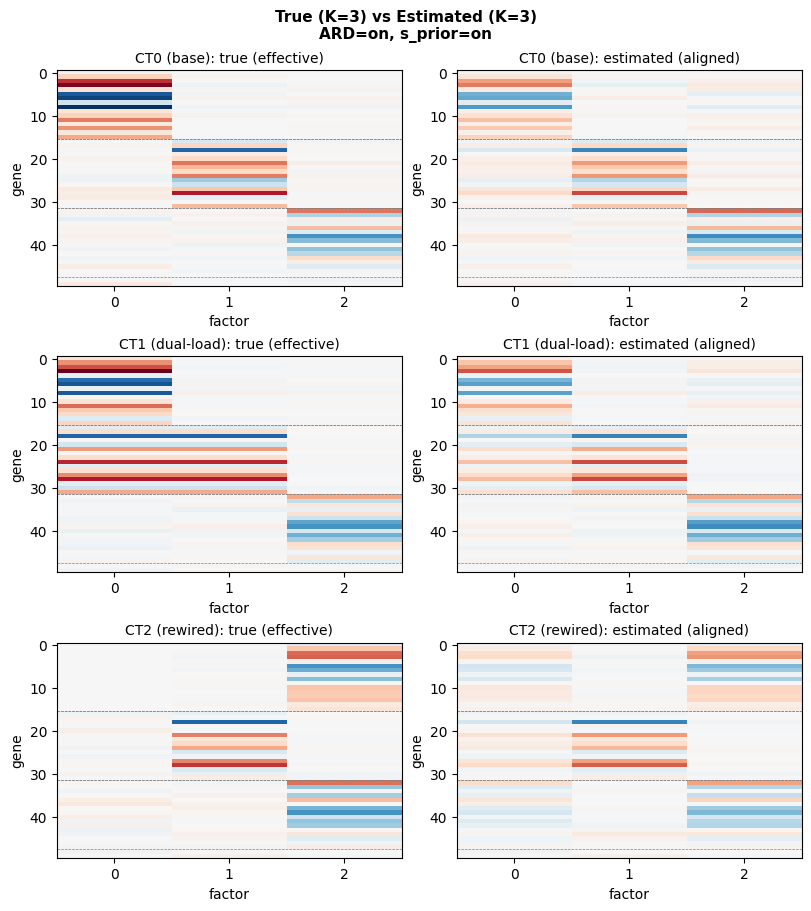

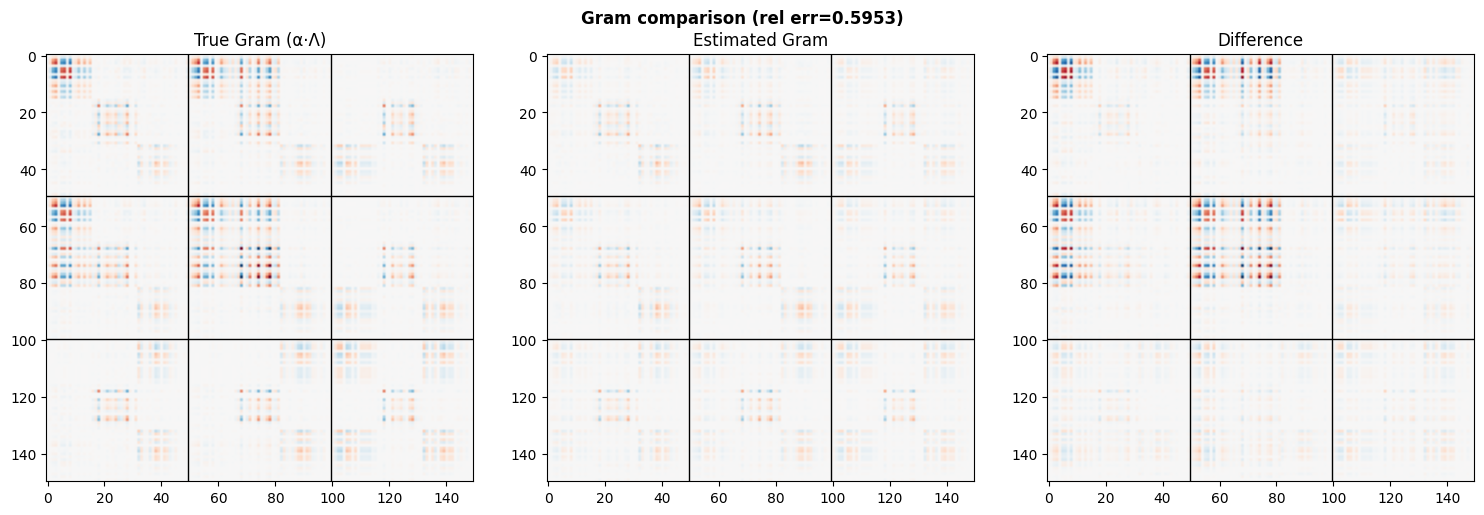

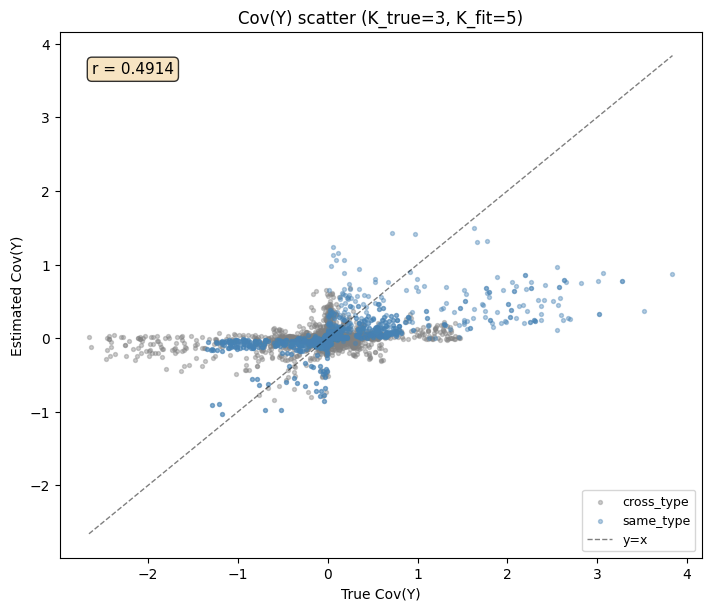

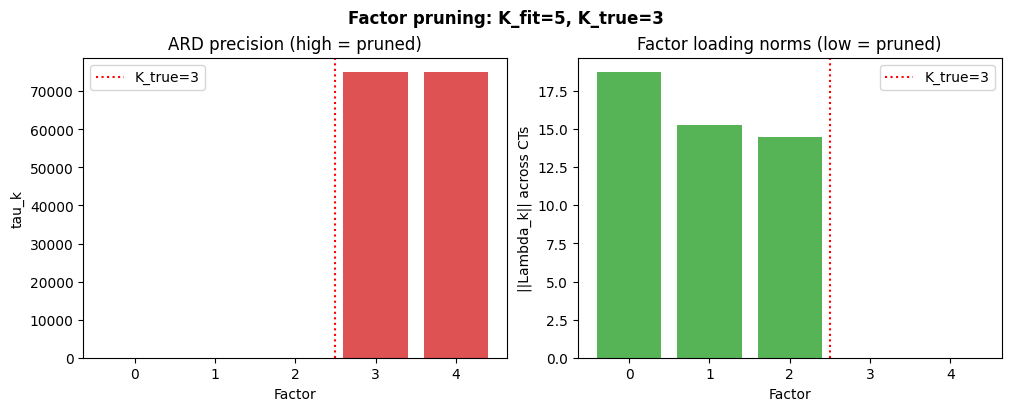


=== Piece 1 complete ===
Lambda_selected: 3 CTs, each (50, 3)
sigma2_est: (50,)
Ready for Piece 2 (MCMC)


In [ ]:
# ── per-CT Lambda heatmaps (Procrustes aligned) ──
K_plot = aligned_lambdas[0].shape[1]
ct_labels = ["CT0 (base)", "CT1 (dual-load)", "CT2 (rewired)"]
vmax = max(np.max(np.abs(np.vstack(true_eff_padded))),
           np.max(np.abs(np.vstack(aligned_lambdas))))

fig, axes = plt.subplots(C, 2, figsize=(max(8, 2*K_plot), 3*C), constrained_layout=True)
if C == 1: axes = np.asarray([axes])
for c in range(C):
    for j, (mat, label) in enumerate(
        [(true_eff_padded[c], "true (effective)"), (aligned_lambdas[c], "estimated (aligned)")]):
        ax = axes[c, j]
        ax.imshow(mat, aspect="auto", vmin=-vmax, vmax=vmax, cmap="RdBu_r")
        ax.set_title(f"{ct_labels[min(c, len(ct_labels)-1)]}: {label}", fontsize=10)
        ax.set_xlabel("factor"); ax.set_ylabel("gene")
        ax.set_xticks(np.arange(mat.shape[1]))
        for gs in GENE_SETS:
            ax.axhline(gs[0]-0.5, color="gray", linewidth=0.5, linestyle="--")
            ax.axhline(gs[-1]+0.5, color="gray", linewidth=0.5, linestyle="--")
        if j == 1 and K_plot > K_TRUE:
            ax.axvline(K_TRUE - 0.5, color="red", linewidth=1.5, linestyle=":",
                       label=f"K_true={K_TRUE}")
fig.suptitle(f"True (K={K_TRUE}) vs Estimated (K={K_plot})\n"
             f"ARD={'on' if USE_ARD else 'off'}, s_prior={'on' if USE_S_PRIOR else 'off'}",
             fontsize=11, fontweight="bold")
plt.show()

# ── Gram comparison ──
true_eff_stack = np.vstack(true_effective)
est_stack_sel = np.vstack(lambdas_selected)
GT = true_eff_stack @ true_eff_stack.T
GE = est_stack_sel @ est_stack_sel.T
vmax_g = max(np.max(np.abs(GT)), np.max(np.abs(GE)))
fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
axes[0].imshow(GT, vmin=-vmax_g, vmax=vmax_g, cmap="RdBu_r"); axes[0].set_title("True Gram (α·Λ)")
axes[1].imshow(GE, vmin=-vmax_g, vmax=vmax_g, cmap="RdBu_r"); axes[1].set_title("Estimated Gram")
diff_g = GT - GE
vmax_d = max(np.max(np.abs(diff_g)), 1e-10)
axes[2].imshow(diff_g, vmin=-vmax_d, vmax=vmax_d, cmap="RdBu_r"); axes[2].set_title("Difference")
for ax in axes:
    for c_b in range(1, C):
        ax.axhline(c_b*G-0.5, color="black", linewidth=1)
        ax.axvline(c_b*G-0.5, color="black", linewidth=1)
rel_err_g = np.linalg.norm(diff_g) / max(np.linalg.norm(GT), 1e-10)
fig.suptitle(f"Gram comparison (rel err={rel_err_g:.4f})", fontsize=12, fontweight="bold")
plt.show()

# ── Cov(Y) scatter (diagonal/same_type/cross_type) ──
rng_plt = np.random.default_rng(42)
n_pairs_plt = 200
pairs_i = rng_plt.integers(0, N, size=n_pairs_plt)
pairs_j = rng_plt.integers(0, N, size=n_pairs_plt)
true_entries, fit_entries, pair_types = [], [], []
for ii, jj in zip(pairs_i, pairs_j):
    i, j = int(ii), int(jj)
    tb = compute_true_cov_block(i, j)
    fb = compute_fit_cov_block(lambdas_selected, sigma2_est, i, j)
    for g in range(0, G, max(1, G//5)):
        for gp in range(0, G, max(1, G//5)):
            true_entries.append(tb[g, gp]); fit_entries.append(fb[g, gp])
            ci, cj = int(cell_types[i]), int(cell_types[j])
            if i == j and g == gp: pair_types.append("diagonal")
            elif ci == cj: pair_types.append("same_type")
            else: pair_types.append("cross_type")

true_entries, fit_entries = np.array(true_entries), np.array(fit_entries)
fig, ax = plt.subplots(1, 1, figsize=(7, 6), constrained_layout=True)
colors_scat = {"diagonal": "red", "same_type": "steelblue", "cross_type": "gray"}
for pt in ["cross_type", "same_type", "diagonal"]:
    mask = np.array([p == pt for p in pair_types])
    if mask.sum() > 0:
        ax.scatter(true_entries[mask], fit_entries[mask], s=8, alpha=0.4,
                   color=colors_scat[pt], label=pt, rasterized=True)
lims = [min(true_entries.min(), fit_entries.min()), max(true_entries.max(), fit_entries.max())]
ax.plot(lims, lims, "k--", linewidth=1, alpha=0.5, label="y=x")
ax.set_xlabel("True Cov(Y)"); ax.set_ylabel("Estimated Cov(Y)")
ax.set_title(f"Cov(Y) scatter (K_true={K_TRUE}, K_fit={K_FIT})")
ax.legend(fontsize=9)
corr_cov = np.corrcoef(true_entries, fit_entries)[0, 1]
ax.text(0.05, 0.92, f"r = {corr_cov:.4f}", transform=ax.transAxes, fontsize=11,
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))
plt.show()

# ── ARD diagnostics ──
if tau_k is not None:
    K_plot_ard = len(tau_k)
    factor_norms_ard = [np.sqrt(sum(np.sum(lambdas_est[c][:, k]**2) for c in range(C)))
                        for k in range(K_plot_ard)]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
    x_ard = np.arange(K_plot_ard)
    colors_ard = ["#2ca02c" if k < K_TRUE else "#d62728" for k in range(K_plot_ard)]
    ax1.bar(x_ard, tau_k, color=colors_ard, alpha=0.8)
    ax1.set_xlabel("Factor"); ax1.set_ylabel("tau_k")
    ax1.set_title("ARD precision (high = pruned)"); ax1.set_xticks(x_ard)
    ax1.axvline(K_TRUE - 0.5, color="red", linestyle=":", linewidth=1.5, label=f"K_true={K_TRUE}")
    ax1.legend()
    ax2.bar(x_ard, factor_norms_ard, color=colors_ard, alpha=0.8)
    ax2.set_xlabel("Factor"); ax2.set_ylabel("||Lambda_k|| across CTs")
    ax2.set_title("Factor loading norms (low = pruned)"); ax2.set_xticks(x_ard)
    ax2.axvline(K_TRUE - 0.5, color="red", linestyle=":", linewidth=1.5, label=f"K_true={K_TRUE}")
    ax2.legend()
    fig.suptitle(f"Factor pruning: K_fit={K_plot_ard}, K_true={K_TRUE}", fontsize=12, fontweight="bold")
    plt.show()

print("\n=== Piece 1 complete ===")
print(f"Lambda_selected: {len(lambdas_selected)} CTs, each {lambdas_selected[0].shape}")
print(f"sigma2_est: {sigma2_est.shape}")
print("Ready for Piece 2 (MCMC)")

# Piece 2 — MCMC

Continues from Piece 1.  All config, utilities, simulation variables,
and MAP results (`lambdas_selected`, `sigma2_est`, `cell_types`, `coords`, etc.) are in scope.

Pipeline: Load R export → Build SPDE/RFF → Build state from MAP → NUTS warmup → Gibbs

## 9 — Load R Export & Build SPDE/RFF Functions

- **SPDE**: FEM matrices define Q(range) via polynomial rescaling of kappa.
- **RFF**: omega_ref at theta_ref=2.0, rescaled on-the-fly as omega*(theta_ref/thetay).
- Both use NU=5.0, same as everything else.

In [ ]:
from scipy.io import mmread
from scipy.special import comb, gammaln

def load_r_export(r_export_dir):
    meta = {}
    with open(os.path.join(r_export_dir, "meta.csv")) as f:
        reader = csv.DictReader(f)
        row = next(reader)
        for key, val in row.items():
            try: meta[key] = int(val)
            except ValueError:
                try: meta[key] = float(val)
                except ValueError: meta[key] = val
    n_v = int(meta["n_v"]); alpha_fem = int(meta["alpha_fem"])
    d_fem = int(meta["d"]); nu_fem = float(meta["nu_fem"])
    nu_rff = float(meta["nu_rff"]); theta_ref = float(meta["theta_ref"])
    M_rff = int(meta["M"])

    def sym_dense(A):
        D = jnp.array(A.toarray(), dtype=jnp.float64)
        return 0.5 * (D + D.T)

    C_fem = sym_dense(mmread(os.path.join(r_export_dir, "fem_C.mtx")).tocsr())
    Gs_fem = tuple(sym_dense(mmread(os.path.join(r_export_dir, f"fem_g{kk}.mtx")).tocsr())
                   for kk in range(1, alpha_fem + 1))
    const_fem = jnp.exp(gammaln(jnp.array(nu_fem)) - gammaln(jnp.array(float(alpha_fem)))) / ((4.0 * math.pi) ** (d_fem / 2.0))
    binom_fem = jnp.array([comb(alpha_fem, kk) for kk in range(alpha_fem + 1)], dtype=jnp.float64)
    A_interp = jnp.array(mmread(os.path.join(r_export_dir, "A.mtx")).toarray(), dtype=jnp.float64)
    A_np = np.array(A_interp)
    omega_ref = jnp.array(np.genfromtxt(os.path.join(r_export_dir, "omega.csv"), delimiter=",", skip_header=1), dtype=jnp.float64)
    b_rff = jnp.array(np.genfromtxt(os.path.join(r_export_dir, "b.csv"), delimiter=",", skip_header=1, usecols=0), dtype=jnp.float64)

    # sanity check: nu should match our global NU
    assert abs(nu_rff - NU) < 0.1, f"nu_rff={nu_rff} != NU={NU}"
    assert abs(nu_fem - NU) < 0.1, f"nu_fem={nu_fem} != NU={NU}"

    return {"n_v": n_v, "alpha_fem": alpha_fem, "d_fem": d_fem, "nu_fem": nu_fem,
            "nu_rff": nu_rff, "theta_ref": theta_ref, "M": M_rff, "C_fem": C_fem,
            "Gs_fem": Gs_fem, "const_fem": const_fem, "binom_fem": binom_fem,
            "A_interp": A_interp, "A_np": A_np, "omega_ref": omega_ref, "b_rff": b_rff}

def make_spde_rff_functions(r):
    n_v=r["n_v"]; C_fem=r["C_fem"]; Gs_fem=r["Gs_fem"]; const_fem=r["const_fem"]
    binom_fem=r["binom_fem"]; alpha_fem=r["alpha_fem"]; d_fem=r["d_fem"]
    nu_fem=r["nu_fem"]; A_interp=r["A_interp"]; omega_ref=r["omega_ref"]
    b_rff_arr=r["b_rff"]; theta_ref=r["theta_ref"]; M_=r["M"]

    @jax.jit
    def Q_from_range(range_param):
        range_param = jnp.maximum(range_param, 1e-12)
        kappa = jnp.sqrt(8.0 * nu_fem) / range_param
        Q = binom_fem[0] * (kappa ** d_fem) * C_fem
        for m in range(1, alpha_fem + 1):
            Q = Q + binom_fem[m] * (kappa ** (d_fem - 2*m)) * Gs_fem[m-1]
        return const_fem * Q

    @jax.jit
    def build_W_from_z(z, range_param):
        zW1, zW2 = z[:n_v], z[n_v:]
        Q = Q_from_range(range_param)
        L = jnp.linalg.cholesky(Q)
        xW1 = jax.scipy.linalg.solve_triangular(L.T, zW1, lower=False)
        xW2 = jax.scipy.linalg.solve_triangular(L.T, zW2, lower=False)
        return A_interp @ xW1, A_interp @ xW2

    @jax.jit
    def build_Z_rff(W, thetay):
        omega_scaled = omega_ref * (theta_ref / thetay)
        phase = W @ omega_scaled.T + b_rff_arr[None, :]
        return jnp.sqrt(2.0 / M_) * jnp.cos(phase)

    @jax.jit
    def build_Z_from_latents(z, log_thetay, logit_rho):
        eps = 1e-3
        thetay = jnp.exp(log_thetay)
        rho = eps + (1.0 - 2.0*eps) / (1.0 + jnp.exp(-logit_rho))
        range_W = rho * thetay
        Q = Q_from_range(range_W)
        LQ = jnp.linalg.cholesky(Q)
        zW1, zW2 = z[:n_v], z[n_v:]
        xW1 = jax.scipy.linalg.solve_triangular(LQ, zW1, lower=True, trans='T')
        xW2 = jax.scipy.linalg.solve_triangular(LQ, zW2, lower=True, trans='T')
        W1 = A_interp @ xW1; W2 = A_interp @ xW2
        W = jnp.stack([W1, W2], axis=1)
        Z = build_Z_rff(W, thetay)
        return Z, W1, W2

    return Q_from_range, build_W_from_z, build_Z_rff, build_Z_from_latents

r_data = load_r_export(R_EXPORT_DIR)
Q_from_range, build_W_from_z, build_Z_rff_fn, build_Z_from_latents = make_spde_rff_functions(r_data)
n_v = r_data["n_v"]; A_np = r_data["A_np"]; M_rff = r_data["M"]

print(f"R export loaded: n_v={n_v}, M={M_rff}")

R export loaded: n_v=409, M=128


## 10 — MCMC Functions

All sampler machinery: collapsed likelihood, NUTS, uncollapse eta,
conjugate Gibbs updates (sigma2, phi, Lambda), slice sampler for s_k.

In [ ]:
# ── priors ──
Y_GN = Y.T  # (G, N) for the sampler
PRIORS = {
    "A_SIGMA": 2.0, "B_SIGMA": np.var(Y_GN) / 4,
    "NU_PHI": 3.0,
    "A_DELTA1": 2.1, "A_DELTA_GT1": 3.1,
    "A_S": 2.0, "B_S": 1.0,
    "LOG_THETAY_PRIOR_MU": np.log(2.5), "LOG_THETAY_PRIOR_SD": 0.5,
    "A_ZETA": 2.0, "B_ZETA": 2.0,
    "A_RHO": 2.0, "B_RHO": 2.0,
    "LOG_ALPHA_PRIOR_MU": 0.0, "LOG_ALPHA_PRIOR_SD": 1.0,
    "EPS_CONSTRAINED": 1e-3,
    "SK_SLICE_W": 1.0,
}
def P(key):
    return PRIORS[key]

# ── per-factor collapsed log-likelihood (JAX, for NUTS) ──
@jax.jit
def collapsed_loglik_jax(Z, zeta, alpha2, u_k, ctilde_k):
    M_loc = Z.shape[1]; alpha = jnp.sqrt(alpha2)
    u_safe = jnp.maximum(u_k, 1e-30)
    d = alpha2 * u_safe; a = 1.0 + (1.0 - zeta) * d
    d_over_a = d / a; c_over_a = alpha * ctilde_k / a
    ZtDZ = Z.T @ (d_over_a[:, None] * Z)
    B = jnp.eye(M_loc) + zeta * ZtDZ
    LB = jnp.linalg.cholesky(B)
    log_det = jnp.sum(jnp.log(a)) + 2.0 * jnp.sum(jnp.log(jnp.diag(LB)))
    csq_da = jnp.sum(ctilde_k**2 / (u_safe * a))
    w = jnp.sqrt(zeta) * (Z.T @ c_over_a)
    v = jax.scipy.linalg.solve_triangular(LB, w, lower=True)
    return -0.5 * (log_det + csq_da - jnp.sum(v * v))

# ── NUTS log-density ──
def make_logdensity_fn(build_Z_fn):
    def logdensity(q, u_k_jax, ctilde_k_jax):
        z = q["z"]; log_ty = q["log_thetay"]; logit_r = q["logit_rho"]
        logit_z = q["logit_zeta"]; log_al = q["log_alpha"]
        eps = 1e-3; alpha2 = jnp.exp(2.0 * log_al)
        zeta_raw = jax.nn.sigmoid(logit_z); zeta = eps + (1.0 - 2.0*eps) * zeta_raw
        Z, _, _ = build_Z_fn(z, log_ty, logit_r)
        ll = collapsed_loglik_jax(Z, zeta, alpha2, u_k_jax, ctilde_k_jax)
        lp_z = -0.5 * jnp.sum(z * z)
        lp_th = -0.5 * ((log_ty - P("LOG_THETAY_PRIOR_MU")) / P("LOG_THETAY_PRIOR_SD"))**2
        rho_raw = jax.nn.sigmoid(logit_r); rho = eps + (1.0 - 2.0*eps) * rho_raw
        lp_rho = ((P("A_RHO")-1)*jnp.log(jnp.maximum(rho, 1e-30))
                  + (P("B_RHO")-1)*jnp.log(jnp.maximum(1-rho, 1e-30))
                  + jnp.log(jnp.maximum(rho_raw*(1-rho_raw), 1e-30))
                  + jnp.log(1-2*eps))
        lp_zeta = ((P("A_ZETA")-1)*jnp.log(jnp.maximum(zeta, 1e-30))
                   + (P("B_ZETA")-1)*jnp.log(jnp.maximum(1-zeta, 1e-30))
                   + jnp.log(jnp.maximum(zeta_raw*(1-zeta_raw), 1e-30))
                   + jnp.log(1-2*eps))
        lp_al = -0.5 * ((log_al - P("LOG_ALPHA_PRIOR_MU")) / P("LOG_ALPHA_PRIOR_SD"))**2
        return ll + lp_z + lp_th + lp_rho + lp_zeta + lp_al
    return logdensity

logdensity_fn = make_logdensity_fn(build_Z_from_latents)

# ── NUTS warmup (per factor) ──
def warmup_nuts_factor_k(k, st, logdensity_fn, rng_key, n_warmup=300):
    Lambda_ck = get_Lambda_ck(st["Lambda"], st["cell_type"], k)
    factor_contrib = (Lambda_ck * st["eta"][:, k:k+1]).T
    R_minus_k = st["Y"] - st["Yhat"] + factor_contrib
    u_k, ctilde_k = compute_base_stats(R_minus_k, Lambda_ck, st["sigma2"])
    u_j = jnp.array(u_k, dtype=jnp.float64)
    ct_j = jnp.array(ctilde_k, dtype=jnp.float64)
    def log_density(params): return logdensity_fn(params, u_j, ct_j)
    q0 = {"z": jnp.array(st["z"][k], dtype=jnp.float64),
           "log_thetay": jnp.array(st["log_thetay"][k], dtype=jnp.float64),
           "logit_rho": jnp.array(st["logit_rho"][k], dtype=jnp.float64),
           "logit_zeta": jnp.array(st["logit_zeta"][k], dtype=jnp.float64),
           "log_alpha": jnp.array(np.log(max(st["alpha"][k], 1e-8)), dtype=jnp.float64)}
    warmup = blackjax.window_adaptation(blackjax.nuts, log_density,
                                         target_acceptance_rate=0.75, progress_bar=True)
    rng_key, subkey = jr.split(rng_key)
    (final_state, tuned_params), _ = warmup.run(subkey, q0, num_steps=n_warmup)
    pos = final_state.position
    return (float(tuned_params["step_size"]),
            jnp.array(tuned_params["inverse_mass_matrix"]),
            rng_key,
            np.array(pos["z"]), float(pos["log_thetay"]),
            float(pos["logit_rho"]), float(pos["logit_zeta"]),
            float(pos["log_alpha"]))

def make_nuts_step_fn(step_size, inv_mass, logdensity_fn):
    nuts_kernel = blackjax.nuts.build_kernel()
    _ss = float(step_size); _im = inv_mass
    @jax.jit
    def step_fn(rng_key, q, u_k_jax, ctilde_k_jax):
        def ld(_q): return logdensity_fn(_q, u_k_jax, ctilde_k_jax)
        state = blackjax.nuts.init(q, ld)
        new_state, info = nuts_kernel(rng_key, state, ld, _ss, _im)
        return new_state.position, info.acceptance_rate
    return step_fn

# ── uncollapse eta (Papaspiliopoulos-Roberts-Sköld) ──
def uncollapse_eta(Z_np, u_k_np, ctilde_k_np, alpha_k, zeta_k, jitter=1e-12):
    Z = np.asarray(Z_np, dtype=np.float64); u = np.asarray(u_k_np, dtype=np.float64)
    c = np.asarray(ctilde_k_np, dtype=np.float64); N_loc, M_loc = Z.shape
    alpha = float(alpha_k); alpha2 = alpha**2; zeta = float(zeta_k)
    a = 1.0 - zeta; b = zeta
    y = np.zeros(N_loc); mask = u > 0; y[mask] = c[mask] / u[mask]
    eta0 = alpha * np.sqrt(max(a, 0.0)) * np.random.standard_normal(N_loc)
    if b > 0: eta0 += alpha * np.sqrt(b) * (Z @ np.random.standard_normal(M_loc))
    eps0 = np.zeros(N_loc); eps0[mask] = np.random.standard_normal(mask.sum()) / np.sqrt(u[mask])
    y0 = eta0 + eps0; v = y - y0
    inv_u = np.empty(N_loc); inv_u[mask] = 1.0/u[mask]; inv_u[~mask] = np.inf
    d = alpha2*a + inv_u; Dinv = np.zeros(N_loc)
    finite = np.isfinite(d); Dinv[finite] = 1.0/d[finite]
    Dinv_v = Dinv * v
    if b <= 0: x = Dinv_v
    else:
        DZ = Dinv[:, None] * Z
        S = (np.eye(M_loc)/(alpha2*b)) + (Z.T @ DZ)
        L = sla.cholesky(S + jitter*np.eye(M_loc), lower=True, check_finite=False)
        t = sla.cho_solve((L, True), Z.T @ Dinv_v, check_finite=False)
        x = Dinv_v - DZ @ t
    corr = alpha2*a*x
    if b > 0: corr += alpha2*b*(Z @ (Z.T @ x))
    return eta0 + corr

# ── Gibbs updates (all conjugate except s_k) ──
def sigma_sk_inv_matrix(s_k, C_val):
    if C_val == 1: return np.array([[1.0]])
    denom = 1 - s_k + C_val * s_k
    return np.eye(C_val) / (1 - s_k) - s_k / ((1 - s_k) * denom) * np.ones((C_val, C_val))

def update_Lambda_k(R_minus_k, eta_k, sigma2, phi_gk, tau_k, s_k, idx_c, C_val, G_val):
    Lambda_new = np.zeros((C_val, G_val))
    eta2_c = np.array([np.sum(eta_k[idx_c[c]]**2) for c in range(C_val)])
    Sigma_inv = sigma_sk_inv_matrix(s_k, C_val)
    for g in range(G_val):
        inv_s2g = 1.0 / sigma2[g]
        Q_like = np.diag(inv_s2g * eta2_c)
        b_like = np.array([inv_s2g * np.sum(eta_k[idx_c[c]] * R_minus_k[g, idx_c[c]]) for c in range(C_val)])
        Q_prior = phi_gk[g] * tau_k * Sigma_inv
        Q_post = Q_like + Q_prior
        L_post = sla.cholesky(Q_post + 1e-14*np.eye(C_val), lower=True, check_finite=False)
        mu_post = sla.cho_solve((L_post, True), b_like, check_finite=False)
        u = np.random.standard_normal(C_val)
        Lambda_new[:, g] = mu_post + sla.solve_triangular(L_post.T, u, lower=False, check_finite=False)
    return Lambda_new

def update_sigma2(Y_gn, Yhat, A_sig, B_sig):
    G_, N_ = Y_gn.shape
    ss = np.sum((Y_gn - Yhat)**2, axis=1)
    a_post = A_sig + N_ / 2.0
    b_post = B_sig + 0.5 * ss
    return 1.0 / np.random.gamma(a_post, 1.0 / b_post, size=G_)

def update_phi(Lambda, tau, s, C_val, G_val, K_val):
    phi_new = np.zeros((G_val, K_val))
    shape_post = (P("NU_PHI") + C_val) / 2.0
    for k in range(K_val):
        Lam_k = Lambda[:, :, k]
        if C_val == 1: Q_gk_vec = Lam_k[0, :]**2
        else:
            sum_sq = np.sum(Lam_k**2, axis=0); sum_lam = np.sum(Lam_k, axis=0)
            denom = 1 - s[k] + C_val * s[k]
            Q_gk_vec = (sum_sq - s[k]*sum_lam**2/denom) / (1 - s[k])
        rate_post = P("NU_PHI")/2.0 + tau[k]/2.0 * Q_gk_vec
        phi_new[:, k] = np.random.gamma(shape_post, 1.0/rate_post)
    return phi_new

# ── slice sampler for s_k ──
def slice_sample_1d(x0, log_target, w=1.0, max_steps=50, max_shrink=200, label=""):
    w = float(w); x0 = float(x0)
    lp0 = float(log_target(x0))
    if not np.isfinite(lp0):
        raise RuntimeError(f"Slice [{label}]: log_target at x0={x0:.4g} is {lp0}")
    log_y = lp0 + np.log(np.random.uniform())
    u = np.random.uniform()
    L = x0 - w*u; R = L + w
    if not (R > L): R = L + max(w, 1e-12)
    j = int(np.floor(max_steps * np.random.uniform())); kk = max_steps - 1 - j
    while j > 0:
        if float(log_target(L)) <= log_y: break
        L -= w; j -= 1
    while kk > 0:
        if float(log_target(R)) <= log_y: break
        R += w; kk -= 1
    for _ in range(max_shrink):
        x1 = L + np.random.uniform()*(R-L)
        lp1 = float(log_target(x1))
        if lp1 >= log_y: return x1, lp1, 0
        if x1 < x0: L = x1
        else: R = x1
    raise RuntimeError(f"Slice [{label}]: {max_shrink} shrinks exhausted.")

def sigma_sk_logdet(s_k, C_val):
    if C_val == 1: return 0.0
    return (C_val-1)*np.log(max(1-s_k, 1e-30)) + np.log(max(1-s_k+C_val*s_k, 1e-30))

def sk_log_conditional(logit_s, Lambda_k, tau_k, C_val, G_val):
    EPS_S = 1e-4
    s_raw = float(1.0/(1.0+np.exp(-float(logit_s))))
    s_k = EPS_S + (1.0-2.0*EPS_S)*s_raw
    log_jac = float(np.log(max(s_raw*(1.0-s_raw)*(1.0-2.0*EPS_S), 1e-30)))
    log_prior = float((P("A_S")-1)*np.log(max(s_k,1e-30)) + (P("B_S")-1)*np.log(max(1-s_k,1e-30)))
    log_det_Sig = sigma_sk_logdet(s_k, C_val)
    if C_val == 1: Q_gk_vec = Lambda_k[0, :]**2
    else:
        sum_sq = np.sum(Lambda_k**2, axis=0); sum_lam = np.sum(Lambda_k, axis=0)
        denom_s = 1 - s_k + C_val*s_k
        Q_gk_vec = (sum_sq - s_k*sum_lam**2/denom_s) / (1 - s_k)
    a_phi = P("NU_PHI")/2.0; nu_c = a_phi + C_val/2.0
    rate_gk = a_phi + tau_k/2.0 * Q_gk_vec
    ell_sum = float(np.sum(-nu_c * np.log(np.maximum(rate_gk, 1e-30))))
    ell_sum -= G_val * 0.5 * log_det_Sig
    return log_prior + ell_sum + log_jac

def update_sk(s_k, Lambda_k, tau_k, k, C_val, G_val, n_steps=1, w=0.5, max_steps=50, max_shrink=200, eps_s=1e-4):
    def log_target(logit_s): return sk_log_conditional(logit_s, Lambda_k, tau_k, C_val, G_val)
    s_k = float(s_k)
    s_raw = (s_k - eps_s) / (1.0 - 2.0*eps_s)
    s_raw = float(np.clip(s_raw, 1e-12, 1.0-1e-12))
    logit_s = float(np.log(s_raw / (1.0 - s_raw)))
    for step in range(n_steps):
        logit_s, _, _ = slice_sample_1d(logit_s, log_target, w=w, max_steps=max_steps,
                                         max_shrink=max_shrink, label=f"s_k{k+1}_step{step}")
    s_raw_new = 1.0 / (1.0 + np.exp(-logit_s))
    return float(eps_s + (1.0 - 2.0*eps_s) * s_raw_new)

print("MCMC functions defined")

MCMC functions defined


## 11 — Build Sampler State from MAP

Lambda & sigma2 from MAP.  Spatial params (z, W, Z_rff) initialized by
projecting slocs onto the SPDE mesh.  eta via uncollapse.  alpha via Woodbury.
phi=1, delta=1, tau=1 (no shrinkage — ARD already pruned).

In [ ]:
# The sampler works with K_TRUE factors (after MAP pruning)
K_SAMPLER = K_TRUE
EPS_C = P("EPS_CONSTRAINED")
idx_c = [np.where(cell_types == c)[0] for c in range(C)]

# Lambda from MAP (after factor selection): list of (G, K_TRUE) → stack to (C, G, K_TRUE)
Lambda_cur = np.stack(lambdas_selected, axis=0)  # (C, G, K_SAMPLER)
sigma2_cur = sigma2_est.copy()

# Spatial hyperparams: prior defaults
log_thetay = np.full(K_SAMPLER, P("LOG_THETAY_PRIOR_MU"))
logit_rho  = np.full(K_SAMPLER, to_logit(np.clip(
    P("A_RHO")/(P("A_RHO")+P("B_RHO")), EPS_C+1e-6, 1-EPS_C-1e-6)))
logit_zeta = np.full(K_SAMPLER, to_logit(np.clip(
    P("A_ZETA")/(P("A_ZETA")+P("B_ZETA")), EPS_C+1e-6, 1-EPS_C-1e-6)))

# s from MAP fit value
s_cur = np.full(K_SAMPLER, np.clip(S_FIT, EPS_C+1e-6, 1-EPS_C-1e-6))

# No shrinkage — ARD already handled pruning
phi_cur   = np.ones((G, K_SAMPLER))
delta_cur = np.ones(K_SAMPLER)
tau_cur   = np.ones(K_SAMPLER)

# z, W, Z_rff: project slocs onto SPDE mesh (identity-like warp)
z_cur = []; W1_cur = np.zeros((N, K_SAMPLER)); W2_cur = np.zeros((N, K_SAMPLER)); Z_rff_cur = []
for k in range(K_SAMPLER):
    thetay_k = float(np.exp(log_thetay[k]))
    rho_k = from_logit(logit_rho[k])
    range_W_k = rho_k * thetay_k
    Q_np = np.array(Q_from_range(jnp.array(float(range_W_k))))
    L_Q = sla.cholesky(Q_np, lower=True, check_finite=False)
    AtA = A_np.T @ A_np; jitter = 1e-12 * np.trace(AtA) / n_v
    L_AtA = sla.cholesky(AtA + jitter * np.eye(n_v), lower=True, check_finite=False)
    x1 = sla.cho_solve((L_AtA, True), A_np.T @ coords[:, 0], check_finite=False)
    x2 = sla.cho_solve((L_AtA, True), A_np.T @ coords[:, 1], check_finite=False)
    z_k = np.concatenate([L_Q.T @ x1, L_Q.T @ x2]); z_cur.append(z_k)
    W1_it, W2_it = build_W_from_z(jnp.array(z_k, dtype=jnp.float64),
                                    jnp.array(range_W_k, dtype=jnp.float64))
    W1_cur[:, k] = np.array(W1_it); W2_cur[:, k] = np.array(W2_it)
    W_k_np = np.column_stack([W1_cur[:, k], W2_cur[:, k]])
    Z_k = np.array(build_Z_rff_fn(jnp.array(W_k_np, dtype=jnp.float64),
                                    jnp.array(thetay_k, dtype=jnp.float64)))
    Z_rff_cur.append(Z_k)

# eta via uncollapse, factor by factor
eta_cur = np.zeros((N, K_SAMPLER))
Yhat = np.zeros((G, N))
for k in range(K_SAMPLER):
    Lambda_ck = get_Lambda_ck(Lambda_cur, cell_types, k)
    R_minus_k = Y_GN - Yhat
    u_k, ctilde_k = compute_base_stats(R_minus_k, Lambda_ck, sigma2_cur)
    zeta_k = from_logit(logit_zeta[k])
    eta_cur[:, k] = uncollapse_eta(Z_rff_cur[k], u_k, ctilde_k, 1.0, zeta_k)
    Yhat += (Lambda_ck * eta_cur[:, k:k+1]).T

# alpha via Woodbury quadratic form
alpha_cur = np.zeros(K_SAMPLER)
for k in range(K_SAMPLER):
    Z_k = np.asarray(Z_rff_cur[k], dtype=np.float64)
    zeta_k = from_logit(logit_zeta[k])
    eta_k = np.asarray(eta_cur[:, k], dtype=np.float64)
    s_val = max(1.0 - zeta_k, 1e-12); r_ratio = zeta_k / s_val
    t = Z_k.T @ eta_k; B = np.eye(M_rff) + r_ratio * (Z_k.T @ Z_k)
    L = sla.cholesky(B + 1e-12*np.eye(M_rff), lower=True, check_finite=False)
    Binv_t = sla.cho_solve((L, True), t, check_finite=False)
    quad_k = max((float(eta_k @ eta_k) / s_val) - (r_ratio / s_val) * float(t @ Binv_t), 0.0)
    alpha_cur[k] = np.sqrt(max(quad_k / N, 1e-8))
alpha2_cur = alpha_cur**2

# Recompute Yhat
Yhat = np.zeros((G, N))
for k in range(K_SAMPLER):
    Lambda_ck_k = Lambda_cur[cell_types, :, k]
    Yhat += (Lambda_ck_k * eta_cur[:, k:k+1]).T

resid_rel = float(np.linalg.norm(Y_GN - Yhat) / np.linalg.norm(Y_GN))
print(f"State built from MAP init:")
print(f"  ||Y-Yhat||/||Y|| = {resid_rel:.4f}")
print(f"  alpha = {np.round(alpha_cur, 3)}")

# Diagnostic subset
gene_sets_ranges = [[gs[0], gs[-1]+1] for gs in GENE_SETS]
gene_idx, cell_idx = pick_diagnostic_subset(K_SAMPLER, G, N, gene_sets_ranges)

# Truth Cov(Y)
covY_true = build_joint_cov(
    W1=np.zeros((N, K_TRUE)), W2=np.zeros((N, K_TRUE)),
    log_thetay=np.log(np.array(true_theta_y)),
    logit_zeta=np.log(np.array(true_zeta) / (1 - np.array(true_zeta))),
    alpha=np.array(true_alpha), Lambda=Lambda_3d, sigma2=sigma2,
    gi=gene_idx, ci=cell_idx, cell_type=cell_types, K_fac=K_TRUE, nu=NU)
# Oops — need truth W1/W2 for the truth Cov(Y)
W1_true_arr = np.column_stack([warped_coords[k][:, 0] for k in range(K_TRUE)])
W2_true_arr = np.column_stack([warped_coords[k][:, 1] for k in range(K_TRUE)])
covY_true = build_joint_cov(
    W1=W1_true_arr, W2=W2_true_arr,
    log_thetay=np.log(np.array(true_theta_y)),
    logit_zeta=np.log(np.array(true_zeta) / (1 - np.array(true_zeta))),
    alpha=np.array(true_alpha), Lambda=Lambda_3d, sigma2=sigma2,
    gi=gene_idx, ci=cell_idx, cell_type=cell_types, K_fac=K_TRUE, nu=NU)
aL_true = compute_alpha_Lambda(np.array(true_alpha), Lambda_3d)

print(f"  Diagnostic subset: {len(gene_idx)} genes, {len(cell_idx)} cells")

State built from MAP init:
  ||Y-Yhat||/||Y|| = 0.3197
  alpha = [1.533 1.435 1.149]
  Diagnostic subset: 9 genes, 15 cells


In [ ]:
# ═══════════════════════════════════════════════════════════════════
# Prewarm: freeze spatial params, equilibrate alpha/eta/Lambda/sigma2
# ═══════════════════════════════════════════════════════════════════
N_PREWARM = 100

# collapsed loglik for slice sampling alpha (numpy, no JAX needed)
def collapsed_loglik_np(Z, zeta, alpha2, u_k, ctilde_k):
    M_loc = Z.shape[1]; alpha = np.sqrt(alpha2)
    u_safe = np.maximum(u_k, 1e-30)
    d = alpha2 * u_safe; a = 1.0 + (1.0 - zeta) * d
    d_over_a = d / a; c_over_a = alpha * ctilde_k / a
    ZtDZ = Z.T @ (d_over_a[:, None] * Z)
    B = np.eye(M_loc) + zeta * ZtDZ
    LB = sla.cholesky(B, lower=True, check_finite=False)
    log_det = np.sum(np.log(a)) + 2.0 * np.sum(np.log(np.diag(LB)))
    csq_da = np.sum(ctilde_k**2 / (u_safe * a))
    w = np.sqrt(zeta) * (Z.T @ c_over_a)
    v = sla.solve_triangular(LB, w, lower=True, check_finite=False)
    return -0.5 * (log_det + csq_da - np.sum(v * v))

def slice_log_alpha_k(log_alpha, Z, zeta, u_k, ctilde_k, n_steps=3, w=0.5):
    mu_alpha = P("LOG_ALPHA_PRIOR_MU"); sd_alpha = P("LOG_ALPHA_PRIOR_SD")
    def log_target(la):
        ll = collapsed_loglik_np(Z, zeta, np.exp(2.0 * la), u_k, ctilde_k)
        return ll - 0.5 * ((la - mu_alpha) / sd_alpha)**2
    current_la = float(log_alpha)
    for step in range(n_steps):
        current_la, _, _ = slice_sample_1d(current_la, log_target, w=w,
                                            label=f"alpha_step{step}")
    return current_la

EPS_C = P("EPS_CONSTRAINED")
print(f"Prewarm ({N_PREWARM} iterations, spatial params frozen) ...")
t0_pw = time.time()

for pw_it in range(N_PREWARM):
    factor_order = np.random.permutation(K_SAMPLER)
    for k in factor_order.tolist():
        Lambda_ck = get_Lambda_ck(Lambda_cur, cell_types, k)
        factor_k_old = (Lambda_ck * eta_cur[:, k:k+1]).T
        R_minus_k = Y_GN - Yhat + factor_k_old
        u_k, ctilde_k = compute_base_stats(R_minus_k, Lambda_ck, sigma2_cur)

        # RFF features from current (frozen) spatial state
        W_k_np = np.column_stack([W1_cur[:, k], W2_cur[:, k]])
        thetay_k = float(np.exp(log_thetay[k]))
        Z_k = np.array(build_Z_rff_fn(jnp.array(W_k_np, dtype=jnp.float64),
                                        jnp.array(thetay_k, dtype=jnp.float64)))
        zeta_k = float(EPS_C + (1 - 2*EPS_C) / (1 + np.exp(-logit_zeta[k])))

        # Slice sample alpha
        log_alpha_new = slice_log_alpha_k(np.log(max(alpha_cur[k], 1e-8)),
                                           Z_k, zeta_k, u_k, ctilde_k)
        alpha_cur[k] = float(np.exp(log_alpha_new))
        alpha2_cur[k] = alpha_cur[k]**2

        # Uncollapse eta
        eta_cur[:, k] = uncollapse_eta(Z_k, u_k, ctilde_k, alpha_cur[k], zeta_k)

        # Update Lambda
        Lambda_cur[:, :, k] = update_Lambda_k(R_minus_k, eta_cur[:, k], sigma2_cur,
                                               phi_cur[:, k], tau_cur[k], s_cur[k],
                                               idx_c, C, G)
        Lambda_ck_new = get_Lambda_ck(Lambda_cur, cell_types, k)
        Yhat += (Lambda_ck_new * eta_cur[:, k:k+1]).T - factor_k_old

    # Global updates
    sigma2_cur = update_sigma2(Y_GN, Yhat, P("A_SIGMA"), P("B_SIGMA"))
    phi_cur = update_phi(Lambda_cur, tau_cur, s_cur, C, G, K_SAMPLER)
    for k in range(K_SAMPLER):
        if C > 1:
            s_cur[k] = update_sk(s_cur[k], Lambda_cur[:, :, k], tau_cur[k], k, C, G,
                                  w=P("SK_SLICE_W"))

    if (pw_it + 1) % 50 == 0 or pw_it == 0 or (pw_it + 1) == N_PREWARM:
        rr = float(np.linalg.norm(Y_GN - Yhat) / np.linalg.norm(Y_GN))
        print(f"  Prewarm {pw_it+1}/{N_PREWARM}: resid={rr:.4f}  "
              f"alpha={np.round(alpha_cur, 3)}")

print(f"Prewarm done in {time.time()-t0_pw:.0f}s")

Prewarm (100 iterations, spatial params frozen) ...
  Prewarm 1/100: resid=0.2657  alpha=[1.586 1.374 1.162]
  Prewarm 50/100: resid=0.2639  alpha=[1.499 1.545 1.266]
  Prewarm 100/100: resid=0.2629  alpha=[1.486 1.319 1.165]
Prewarm done in 76s


## 12 — NUTS Warmup

In [ ]:
N_NUTS_WARMUP_VAL = 50  # from config

rng_key = jr.PRNGKey(199)
nuts_step_sizes = []; nuts_inv_masses = []; nuts_step_fns = []

# Pack state dict for warmup function
st = {"Y": Y_GN, "Yhat": Yhat, "Lambda": Lambda_cur, "sigma2": sigma2_cur,
      "eta": eta_cur, "alpha": alpha_cur, "cell_type": cell_types,
      "z": z_cur, "log_thetay": log_thetay, "logit_rho": logit_rho,
      "logit_zeta": logit_zeta}

print(f"NUTS warmup ({N_NUTS_WARMUP_VAL} steps per factor) ...")
for k in range(K_SAMPLER):
    print(f"  Factor {k+1}/{K_SAMPLER} ...")
    (ss_k, im_k, rng_key, z_k, lt_k, lr_k, lz_k, la_k) = warmup_nuts_factor_k(
        k, st, logdensity_fn, rng_key, n_warmup=N_NUTS_WARMUP_VAL)
    nuts_step_sizes.append(ss_k); nuts_inv_masses.append(im_k)
    nuts_step_fns.append(make_nuts_step_fn(ss_k, im_k, logdensity_fn))
    z_cur[k] = z_k; log_thetay[k] = lt_k; logit_rho[k] = lr_k; logit_zeta[k] = lz_k
    alpha_cur[k] = float(np.exp(la_k)); alpha2_cur[k] = alpha_cur[k]**2
    Z_jax, W1_new, W2_new = build_Z_from_latents(
        jnp.array(z_cur[k], dtype=jnp.float64),
        jnp.array(log_thetay[k], dtype=jnp.float64),
        jnp.array(logit_rho[k], dtype=jnp.float64))
    W1_cur[:, k] = np.array(W1_new); W2_cur[:, k] = np.array(W2_new)
    Z_rff_cur[k] = np.array(Z_jax)

# Recompute Yhat
Yhat = np.zeros((G, N))
for k in range(K_SAMPLER):
    Lambda_ck_k = Lambda_cur[cell_types, :, k]
    Yhat += (Lambda_ck_k * eta_cur[:, k:k+1]).T

resid_rel = float(np.linalg.norm(Y_GN - Yhat) / np.linalg.norm(Y_GN))
print(f"\nPost-NUTS warmup: ||Y-Yhat||/||Y|| = {resid_rel:.4f}")
print(f"  alpha  = {np.round(alpha_cur, 3)}")
print(f"  thetay = {np.round(np.exp(log_thetay), 3)}")
print(f"  zeta   = {np.round([from_logit(l) for l in logit_zeta], 3)}")

NUTS warmup (50 steps per factor) ...
  Factor 1/3 ...
Running window adaptation


<div><progress max="50" value="50"></progress> 100.00% [50/50 00:00&lt;?]</div>

  Factor 2/3 ...
Running window adaptation


<div><progress max="50" value="50"></progress> 100.00% [50/50 00:00&lt;?]</div>

  Factor 3/3 ...
Running window adaptation


<div><progress max="50" value="50"></progress> 100.00% [50/50 00:00&lt;?]</div>


Post-NUTS warmup: ||Y-Yhat||/||Y|| = 0.2629
  alpha  = [1.474 2.22  1.234]
  thetay = [2.548 5.333 6.293]
  zeta   = [0.503 0.768 0.419]


## 13 — Gibbs Sampler with Live Diagnostics

Per-factor Gauss-Seidel: NUTS on spatial params → uncollapse eta → update Lambda.
Then sigma2 (conjugate IG), phi (conjugate Gamma), s_k (slice).
Re-warms NUTS if acceptance drops.
Live plots every PLOT_EVERY iterations.

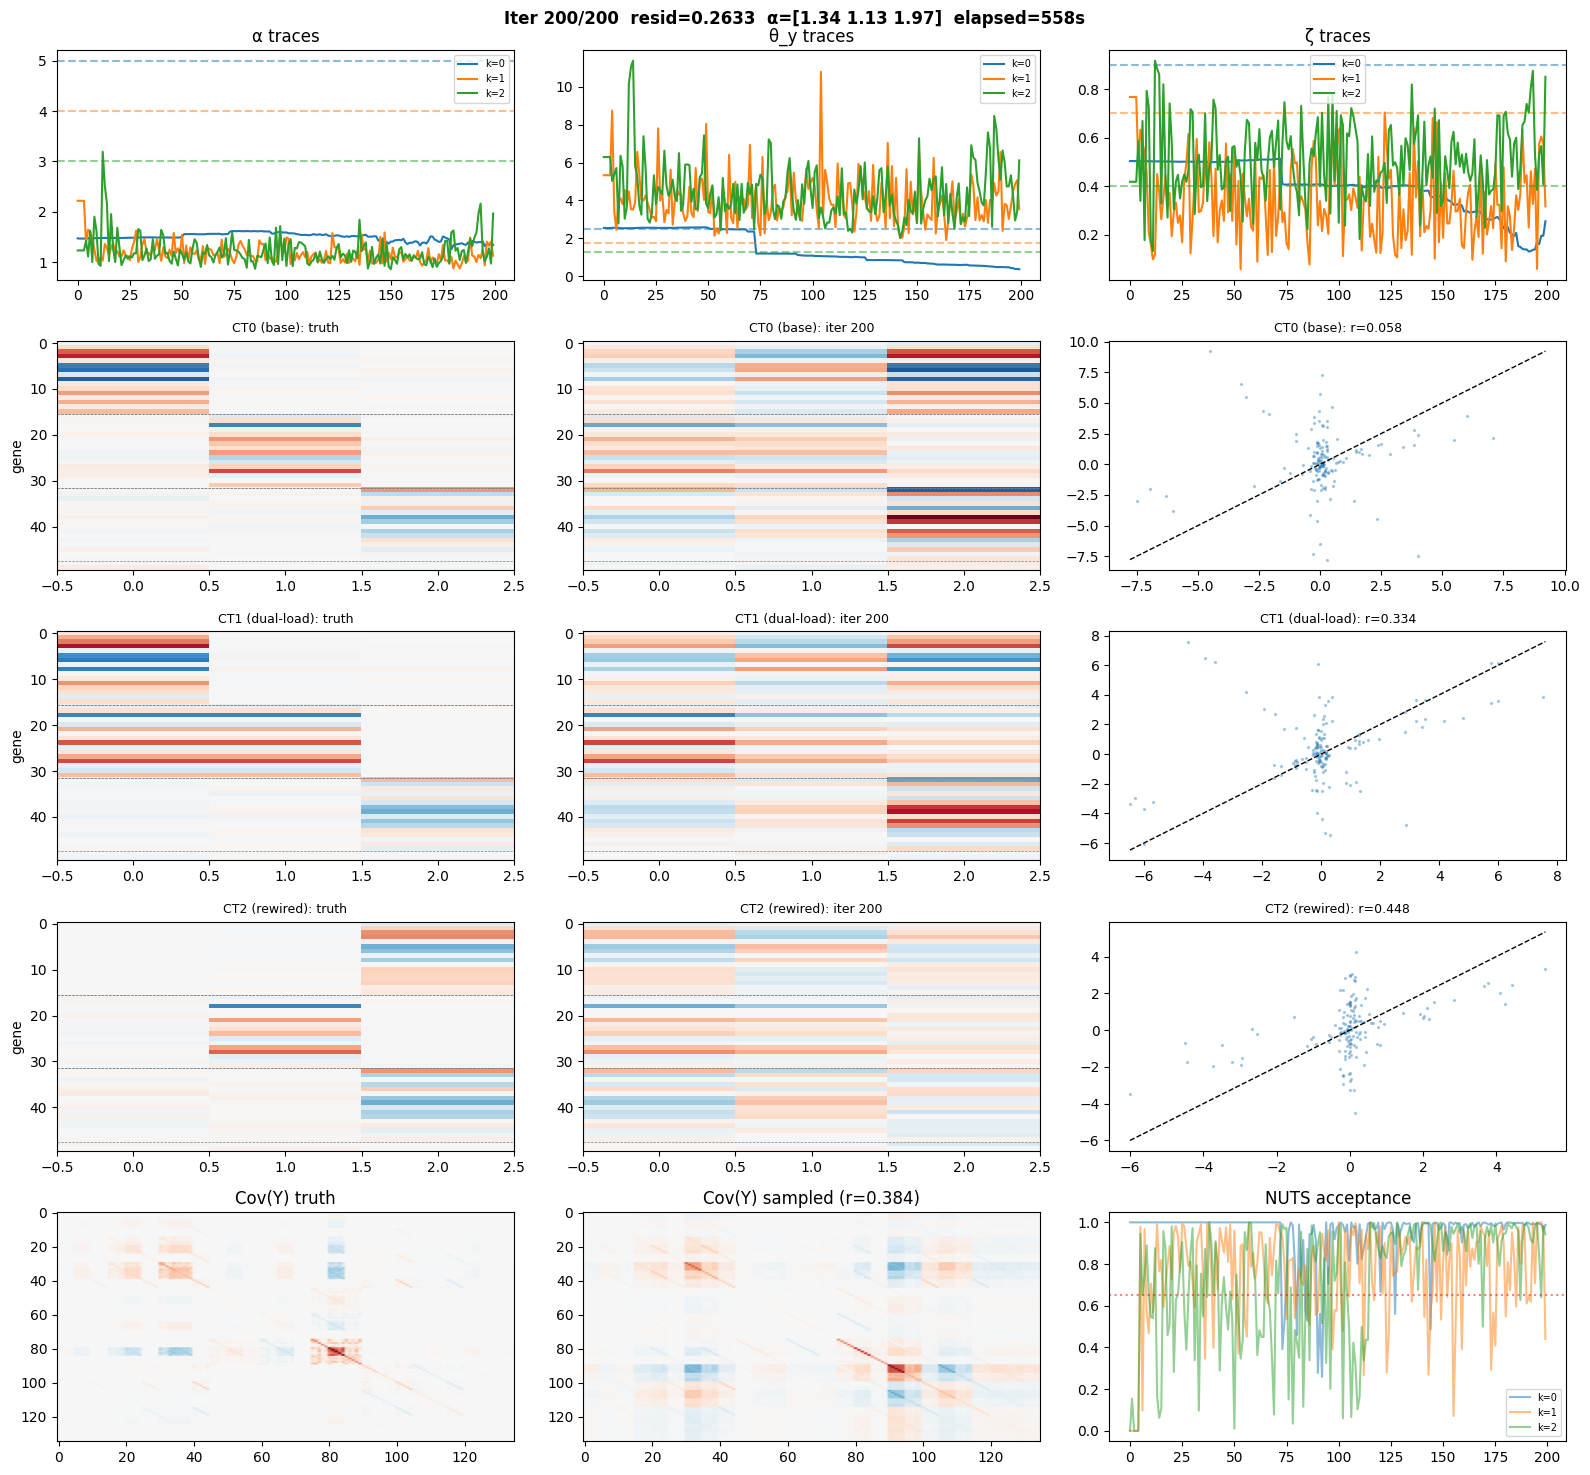

  Iter 200/200  resid=0.2633  alpha=[1.343 1.128 1.968]  thetay=[0.363 3.539 6.115]  elapsed=561s

Gibbs done: 200 iterations in 561s
  Final alpha:  [1.343 1.128 1.968]  vs truth [5.0, 4.0, 3.0]
  Final thetay: [0.363 3.539 6.115]  vs truth [2.5, 1.75, 1.25]
  Final rho:    [0.614 0.534 0.319]  vs truth [0.6, 0.7, 0.8]
  Final zeta:   [0.256 0.318 0.851]  vs truth [0.9, 0.7, 0.4]


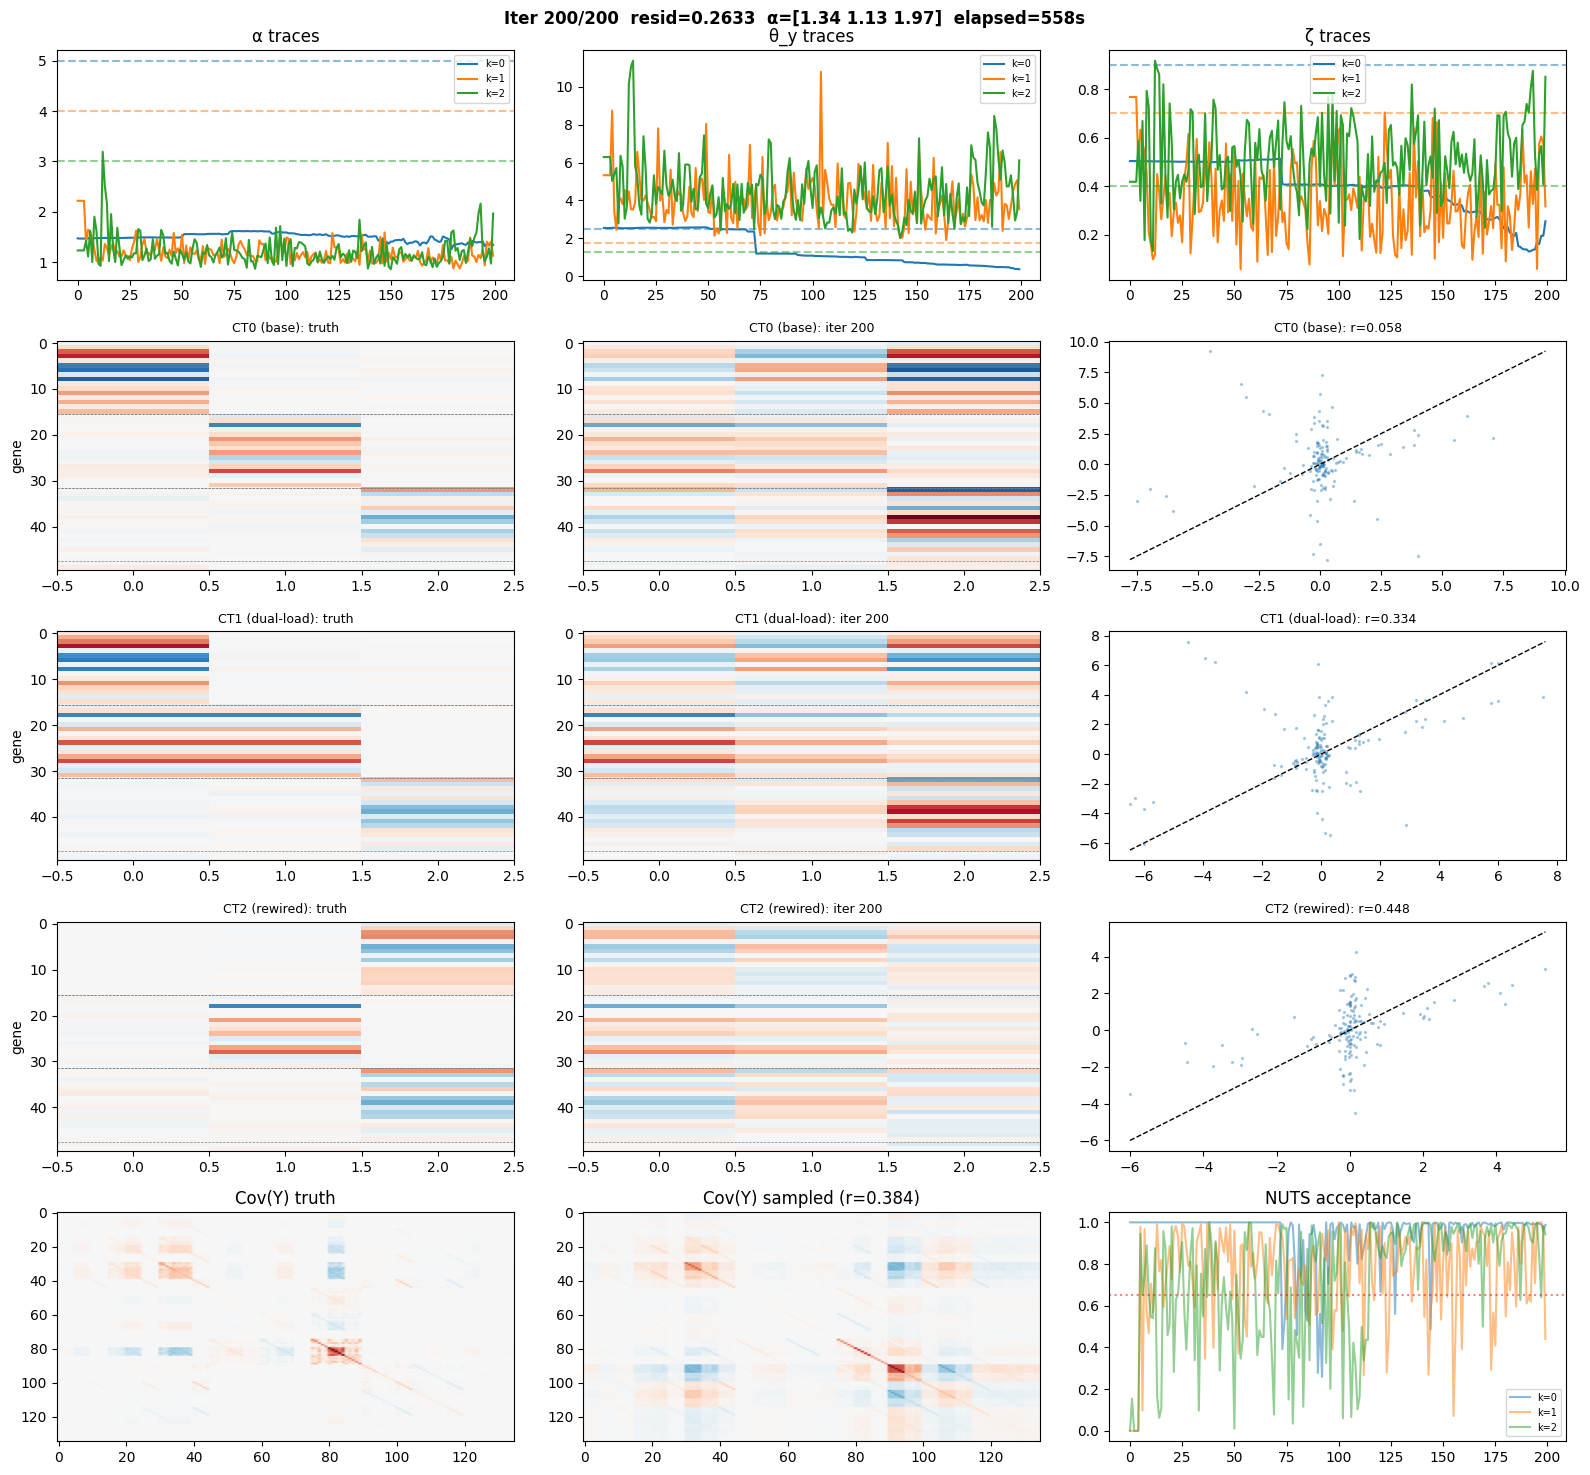

In [ ]:
N_GIBBS_VAL   = 200
PLOT_EVERY    = 10
SNAPSHOT_EVERY = 10
NUTS_ACC_THRESHOLD = 0.5
NUTS_ACC_WINDOW    = 5
REWARM_N_STEPS     = 50

K_S = K_SAMPLER

traces = {
    "alpha": np.zeros((N_GIBBS_VAL, K_S)),
    "log_thetay": np.zeros((N_GIBBS_VAL, K_S)),
    "logit_rho": np.zeros((N_GIBBS_VAL, K_S)),
    "logit_zeta": np.zeros((N_GIBBS_VAL, K_S)),
    "sigma2": np.zeros((N_GIBBS_VAL, G)),
    "s": np.zeros((N_GIBBS_VAL, K_S)),
    "nuts_accept": np.zeros((N_GIBBS_VAL, K_S)),
    "resid_rel": np.zeros(N_GIBBS_VAL),
    "delta_eta": np.zeros((N_GIBBS_VAL, K_S)),
    "delta_W": np.zeros((N_GIBBS_VAL, K_S)),
    "delta_Lambda": np.zeros((N_GIBBS_VAL, K_S)),
}
snapshot_iters = []; snapshots_aL = []; snapshots_covY = []

nuts_acc_history = {k: [] for k in range(K_S)}
eta_prev = eta_cur.copy(); W1_prev = W1_cur.copy(); W2_prev = W2_cur.copy()
Lambda_prev = Lambda_cur.copy()

ct_labels = ["CT0 (base)", "CT1 (dual-load)", "CT2 (rewired)"]
n_plot_rows = 1 + C + 1  # traces + C Lambda rows + bottom row
fig_live, axes_live = plt.subplots(n_plot_rows, 3, figsize=(16, 3*n_plot_rows))

t0_gibbs = time.time()

for it in range(N_GIBBS_VAL):
    factor_order = np.random.permutation(K_S)
    for k in factor_order.tolist():
        Lambda_ck = get_Lambda_ck(Lambda_cur, cell_types, k)
        factor_k_old = (Lambda_ck * eta_cur[:, k:k+1]).T
        R_minus_k = Y_GN - Yhat + factor_k_old
        u_k_np, ctilde_k_np = compute_base_stats(R_minus_k, Lambda_ck, sigma2_cur)
        u_k_jax = jnp.array(u_k_np, dtype=jnp.float64)
        ctilde_k_jax = jnp.array(ctilde_k_np, dtype=jnp.float64)

        # NUTS step
        q = {"z": jnp.array(z_cur[k], dtype=jnp.float64),
             "log_thetay": jnp.array(log_thetay[k], dtype=jnp.float64),
             "logit_rho": jnp.array(logit_rho[k], dtype=jnp.float64),
             "logit_zeta": jnp.array(logit_zeta[k], dtype=jnp.float64),
             "log_alpha": jnp.array(np.log(max(alpha_cur[k], 1e-8)), dtype=jnp.float64)}
        rng_key, sk = jr.split(rng_key)
        q_new, acc = nuts_step_fns[k](sk, q, u_k_jax, ctilde_k_jax)
        z_cur[k] = np.array(q_new["z"])
        log_thetay[k] = float(q_new["log_thetay"])
        logit_rho[k] = float(q_new["logit_rho"])
        logit_zeta[k] = float(q_new["logit_zeta"])
        alpha_cur[k] = float(np.exp(float(q_new["log_alpha"])))
        alpha2_cur[k] = alpha_cur[k]**2
        zeta_k = from_logit(logit_zeta[k])
        traces["nuts_accept"][it, k] = float(acc)

        Z_jax, W1_new, W2_new = build_Z_from_latents(
            jnp.array(z_cur[k], dtype=jnp.float64),
            jnp.array(log_thetay[k], dtype=jnp.float64),
            jnp.array(logit_rho[k], dtype=jnp.float64))
        W1_cur[:, k] = np.array(W1_new); W2_cur[:, k] = np.array(W2_new)
        Z_rff_cur[k] = np.array(Z_jax)

        eta_cur[:, k] = uncollapse_eta(Z_rff_cur[k], u_k_np, ctilde_k_np,
                                        alpha_cur[k], zeta_k)
        Lambda_cur[:, :, k] = update_Lambda_k(R_minus_k, eta_cur[:, k], sigma2_cur,
                                               phi_cur[:, k], tau_cur[k], s_cur[k],
                                               idx_c, C, G)
        Lambda_ck_new = get_Lambda_ck(Lambda_cur, cell_types, k)
        Yhat += (Lambda_ck_new * eta_cur[:, k:k+1]).T - factor_k_old

    # Global updates
    sigma2_cur = update_sigma2(Y_GN, Yhat, P("A_SIGMA"), P("B_SIGMA"))
    phi_cur = update_phi(Lambda_cur, tau_cur, s_cur, C, G, K_S)
    for k in range(K_S):
        if C > 1:
            s_cur[k] = update_sk(s_cur[k], Lambda_cur[:, :, k], tau_cur[k], k, C, G,
                                  w=P("SK_SLICE_W"))

    # Movement traces
    for k in range(K_S):
        traces["delta_eta"][it, k] = float(np.linalg.norm(eta_cur[:, k] - eta_prev[:, k]))
        traces["delta_W"][it, k] = float(np.sqrt(
            np.sum((W1_cur[:, k]-W1_prev[:, k])**2) + np.sum((W2_cur[:, k]-W2_prev[:, k])**2)))
        traces["delta_Lambda"][it, k] = float(np.linalg.norm(Lambda_cur[:, :, k] - Lambda_prev[:, :, k]))
    eta_prev[:] = eta_cur; W1_prev[:] = W1_cur; W2_prev[:] = W2_cur; Lambda_prev[:] = Lambda_cur

    # Re-warm check
    for k in range(K_S):
        nuts_acc_history[k].append(traces["nuts_accept"][it, k])
        if len(nuts_acc_history[k]) >= NUTS_ACC_WINDOW:
            recent = nuts_acc_history[k][-NUTS_ACC_WINDOW:]
            if all(a < NUTS_ACC_THRESHOLD for a in recent):
                print(f"  Iter {it+1}: re-warming NUTS for factor {k+1}")
                st_rw = {"Y": Y_GN, "Yhat": Yhat, "Lambda": Lambda_cur,
                         "sigma2": sigma2_cur, "eta": eta_cur, "alpha": alpha_cur,
                         "cell_type": cell_types, "z": z_cur,
                         "log_thetay": log_thetay, "logit_rho": logit_rho,
                         "logit_zeta": logit_zeta}
                (ss_new, im_new, rng_key, z_k, lt_k, lr_k, lz_k, la_k) = warmup_nuts_factor_k(
                    k, st_rw, logdensity_fn, rng_key, n_warmup=REWARM_N_STEPS)
                nuts_step_sizes[k] = ss_new; nuts_inv_masses[k] = im_new
                nuts_step_fns[k] = make_nuts_step_fn(ss_new, im_new, logdensity_fn)
                z_cur[k] = z_k; log_thetay[k] = lt_k; logit_rho[k] = lr_k; logit_zeta[k] = lz_k
                alpha_cur[k] = float(np.exp(la_k)); alpha2_cur[k] = alpha_cur[k]**2
                Z_jax, W1_new, W2_new = build_Z_from_latents(
                    jnp.array(z_cur[k], dtype=jnp.float64),
                    jnp.array(log_thetay[k], dtype=jnp.float64),
                    jnp.array(logit_rho[k], dtype=jnp.float64))
                W1_cur[:, k] = np.array(W1_new); W2_cur[:, k] = np.array(W2_new)
                Z_rff_cur[k] = np.array(Z_jax)
                nuts_acc_history[k] = []

    # Store traces
    rr = float(np.linalg.norm(Y_GN - Yhat) / np.linalg.norm(Y_GN))
    traces["alpha"][it] = alpha_cur.copy()
    traces["log_thetay"][it] = log_thetay.copy()
    traces["logit_rho"][it] = logit_rho.copy()
    traces["logit_zeta"][it] = logit_zeta.copy()
    traces["sigma2"][it] = sigma2_cur.copy()
    traces["s"][it] = s_cur.copy()
    traces["resid_rel"][it] = rr

    # Snapshots
    if (it+1) % SNAPSHOT_EVERY == 0:
        aL_snap = compute_alpha_Lambda(alpha_cur, Lambda_cur)
        covY_snap = build_joint_cov(W1=W1_cur, W2=W2_cur, log_thetay=log_thetay,
                    logit_zeta=logit_zeta, alpha=alpha_cur, Lambda=Lambda_cur,
                    sigma2=sigma2_cur, gi=gene_idx, ci=cell_idx,
                    cell_type=cell_types, K_fac=K_S, nu=NU)
        snapshots_aL.append(aL_snap.copy()); snapshots_covY.append(covY_snap.copy())
        snapshot_iters.append(it+1)

    # ── live plot ──
    if (it+1) % PLOT_EVERY == 0 or it == 0 or it == N_GIBBS_VAL - 1:
        elapsed = time.time() - t0_gibbs
        clear_output(wait=True)
        for ax in axes_live.flat: ax.clear()

        # Row 0: traces
        for k in range(K_S):
            axes_live[0,0].plot(traces["alpha"][:it+1, k], label=f"k={k}")
            axes_live[0,0].axhline(TRUE_ALPHA[k], color=f"C{k}", ls="--", alpha=0.5)
        axes_live[0,0].set_title("α traces"); axes_live[0,0].legend(fontsize=7)

        for k in range(K_S):
            axes_live[0,1].plot(np.exp(traces["log_thetay"][:it+1, k]), label=f"k={k}")
            axes_live[0,1].axhline(TRUE_THETA_Y[k], color=f"C{k}", ls="--", alpha=0.5)
        axes_live[0,1].set_title("θ_y traces"); axes_live[0,1].legend(fontsize=7)

        for k in range(K_S):
            zt = 1e-3 + (1-2e-3)/(1+np.exp(-traces["logit_zeta"][:it+1, k]))
            axes_live[0,2].plot(zt, label=f"k={k}")
            axes_live[0,2].axhline(TRUE_ZETA[k], color=f"C{k}", ls="--", alpha=0.5)
        axes_live[0,2].set_title("ζ traces"); axes_live[0,2].legend(fontsize=7)

        # Rows 1..C: per-CT α·Λ heatmaps
        aL_cur = compute_alpha_Lambda(alpha_cur, Lambda_cur)
        vmax = max(np.abs(aL_true).max(), np.abs(aL_cur).max())
        for c in range(C):
            row = 1 + c
            axes_live[row, 0].imshow(aL_true[c], aspect="auto", vmin=-vmax, vmax=vmax, cmap="RdBu_r")
            axes_live[row, 0].set_title(f"{ct_labels[c]}: truth", fontsize=9)
            axes_live[row, 0].set_ylabel("gene")
            for gs in GENE_SETS:
                axes_live[row, 0].axhline(gs[0]-0.5, color="gray", lw=0.5, ls="--")
                axes_live[row, 0].axhline(gs[-1]+0.5, color="gray", lw=0.5, ls="--")

            axes_live[row, 1].imshow(aL_cur[c], aspect="auto", vmin=-vmax, vmax=vmax, cmap="RdBu_r")
            axes_live[row, 1].set_title(f"{ct_labels[c]}: iter {it+1}", fontsize=9)
            for gs in GENE_SETS:
                axes_live[row, 1].axhline(gs[0]-0.5, color="gray", lw=0.5, ls="--")
                axes_live[row, 1].axhline(gs[-1]+0.5, color="gray", lw=0.5, ls="--")

            axes_live[row, 2].scatter(aL_true[c].ravel(), aL_cur[c].ravel(), s=2, alpha=0.3)
            lc = [min(aL_true[c].min(), aL_cur[c].min()), max(aL_true[c].max(), aL_cur[c].max())]
            axes_live[row, 2].plot(lc, lc, "k--", lw=1)
            rc = np.corrcoef(aL_true[c].ravel(), aL_cur[c].ravel())[0,1]
            axes_live[row, 2].set_title(f"{ct_labels[c]}: r={rc:.3f}", fontsize=9)

        # Bottom row: Cov(Y) heatmaps + NUTS acceptance
        covY_cur = build_joint_cov(W1=W1_cur, W2=W2_cur, log_thetay=log_thetay,
                    logit_zeta=logit_zeta, alpha=alpha_cur, Lambda=Lambda_cur,
                    sigma2=sigma2_cur, gi=gene_idx, ci=cell_idx,
                    cell_type=cell_types, K_fac=K_S, nu=NU)
        vlim_cov = max(np.abs(covY_true).max(), np.abs(covY_cur).max()) * 1.05
        axes_live[-1, 0].imshow(covY_true, cmap="RdBu_r", aspect="auto", vmin=-vlim_cov, vmax=vlim_cov)
        axes_live[-1, 0].set_title("Cov(Y) truth")
        axes_live[-1, 1].imshow(covY_cur, cmap="RdBu_r", aspect="auto", vmin=-vlim_cov, vmax=vlim_cov)
        corr_cov = np.corrcoef(covY_true.ravel(), covY_cur.ravel())[0,1]
        axes_live[-1, 1].set_title(f"Cov(Y) sampled (r={corr_cov:.3f})")

        for k in range(K_S):
            axes_live[-1, 2].plot(traces["nuts_accept"][:it+1, k], alpha=0.5, label=f"k={k}")
        axes_live[-1, 2].axhline(0.65, color="red", ls=":", alpha=0.5)
        axes_live[-1, 2].set_title("NUTS acceptance"); axes_live[-1, 2].legend(fontsize=7)

        fig_live.suptitle(f"Iter {it+1}/{N_GIBBS_VAL}  resid={rr:.4f}  "
                          f"α={np.round(alpha_cur,2)}  elapsed={elapsed:.0f}s", fontweight="bold")
        plt.tight_layout()
        display(fig_live)

    # Print every 50
    if (it+1) % 50 == 0 or it == 0:
        print(f"  Iter {it+1}/{N_GIBBS_VAL}  resid={rr:.4f}  alpha={np.round(alpha_cur,3)}  "
              f"thetay={np.round(np.exp(log_thetay),3)}  elapsed={time.time()-t0_gibbs:.0f}s")

print(f"\nGibbs done: {N_GIBBS_VAL} iterations in {time.time()-t0_gibbs:.0f}s")
print(f"  Final alpha:  {np.round(alpha_cur, 3)}  vs truth {TRUE_ALPHA}")
print(f"  Final thetay: {np.round(np.exp(log_thetay), 3)}  vs truth {TRUE_THETA_Y}")
print(f"  Final rho:    {np.round([from_logit(l) for l in logit_rho], 3)}  vs truth {TRUE_RHO}")
print(f"  Final zeta:   {np.round([from_logit(l) for l in logit_zeta], 3)}  vs truth {TRUE_ZETA}")

## 14 — Final Summary Diagnostics

Posterior summaries using snapshots after burn-in, matching
`plot_alphaLambda_summary.py` and `plot_covY_summary.py`.

In [ ]:
BURNIN = N_GIBBS_VAL // 2

snap_aL = np.array(snapshots_aL)       # (n_snap, C, G, K)
snap_covY = np.array(snapshots_covY)    # (n_snap, n_sub, n_sub)
snap_iters_arr = np.array(snapshot_iters)

mask_post = snap_iters_arr > BURNIN
snap_aL_post = snap_aL[mask_post]
snap_covY_post = snap_covY[mask_post]
print(f"Post-burn-in snapshots: {mask_post.sum()} (iters {snap_iters_arr[mask_post][0]}-{snap_iters_arr[mask_post][-1]})")

# ── α·Λ summary: 4 rows × C columns ──
aL_mean = np.mean(snap_aL_post, axis=0)
aL_q05  = np.quantile(snap_aL_post, 0.05, axis=0)
aL_q95  = np.quantile(snap_aL_post, 0.95, axis=0)

vlim_aL = max(np.abs(aL_true).max(), np.abs(aL_mean).max(),
              np.abs(aL_q05).max(), np.abs(aL_q95).max()) * 1.05

row_labels = ["True", "Posterior Mean", "Posterior Q05", "Posterior Q95"]
row_data = [aL_true, aL_mean, aL_q05, aL_q95]

fig, axes = plt.subplots(4, C, figsize=(max(3.5*C, 8), 14), layout="constrained")
if C == 1: axes = axes[:, np.newaxis]
for row in range(4):
    for c in range(C):
        im = axes[row, c].imshow(row_data[row][c], cmap="RdBu_r", aspect="auto",
                                  vmin=-vlim_aL, vmax=vlim_aL)
        axes[row, c].set_title(f"{row_labels[row]} — CT{c}", fontsize=8)
        axes[row, c].set_xticks(range(K_S))
        axes[row, c].set_xticklabels([f"k{k+1}" for k in range(K_S)], fontsize=7)
        if c == 0: axes[row, c].set_ylabel("Gene", fontsize=8)
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
fig.suptitle(f"α·Λ Summary (burn-in={BURNIN}, {mask_post.sum()} samples)", fontsize=12)
plt.show()

# ── Cov(Y) summary: 2×2 ──
covY_mean = np.mean(snap_covY_post, axis=0)
covY_q05  = np.quantile(snap_covY_post, 0.05, axis=0)
covY_q95  = np.quantile(snap_covY_post, 0.95, axis=0)

vlim_cov = max(np.abs(covY_true).max(), np.abs(covY_mean).max(),
               np.abs(covY_q05).max(), np.abs(covY_q95).max()) * 1.05

fig, axes = plt.subplots(2, 2, figsize=(14, 10), layout="constrained")
panels = [
    (axes[0,0], covY_true, "True Cov(Y)"),
    (axes[0,1], covY_mean, "Posterior Mean Cov(Y)"),
    (axes[1,0], covY_q05,  "Posterior Q05 Cov(Y)"),
    (axes[1,1], covY_q95,  "Posterior Q95 Cov(Y)"),
]
for ax, mat, title in panels:
    im = ax.imshow(mat, cmap="RdBu_r", aspect="auto", vmin=-vlim_cov, vmax=vlim_cov)
    ax.set_title(title, fontsize=10, fontweight="bold")
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6, pad=0.08)
fig.suptitle(f"Cov(Y) Summary (burn-in={BURNIN}, {mask_post.sum()} samples)", fontsize=12)
plt.show()

# ── Additional traces ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0,0].plot(traces["resid_rel"]); axes[0,0].set_title("||Y-Ŷ||/||Y||")
for k in range(K_S):
    axes[0,1].plot(traces["nuts_accept"][:, k], alpha=0.5, label=f"k={k}")
axes[0,1].axhline(0.65, color="red", ls=":", alpha=0.5)
axes[0,1].set_title("NUTS acceptance"); axes[0,1].legend(fontsize=8)

axes[1,0].scatter(sigma2, np.mean(traces["sigma2"][BURNIN:], axis=0), s=12)
lims_s = [0, max(sigma2.max(), np.mean(traces["sigma2"][BURNIN:], axis=0).max())*1.1]
axes[1,0].plot(lims_s, lims_s, "k--"); axes[1,0].set_xlabel("True σ²")
axes[1,0].set_ylabel("Posterior mean σ²"); axes[1,0].set_title("σ² recovery")

for k in range(K_S):
    rho_trace = [from_logit(l) for l in traces["logit_rho"][:, k]]
    axes[1,1].plot(rho_trace, label=f"k={k}")
    axes[1,1].axhline(TRUE_RHO[k], color=f"C{k}", ls="--", alpha=0.5)
axes[1,1].set_title("ρ traces"); axes[1,1].legend(fontsize=8)

plt.suptitle("Final diagnostics", fontweight="bold")
plt.tight_layout(); plt.show()

print("\n=== Final vs Truth ===")
print(f"  alpha: {np.round(alpha_cur, 3)} vs {TRUE_ALPHA}")
print(f"  theta: {np.round(np.exp(log_thetay), 3)} vs {TRUE_THETA_Y}")
print(f"  rho:   {np.round([from_logit(l) for l in logit_rho], 3)} vs {TRUE_RHO}")
print(f"  zeta:  {np.round([from_logit(l) for l in logit_zeta], 3)} vs {TRUE_ZETA}")